# Supplementary Notebook 19: Adjusted Rand Index for Peptide Grouping Quality

- **License:** [Creative Commons Attribution-NonCommercial 4.0 International License](https://creativecommons.org/licenses/by-nc/4.0/)
- **Version:** 0.1
- **Date:** 2026-03-15

## Overview

This notebook evaluates peptide grouping quality using the Adjusted Rand Index (ARI), a clustering metric that quantifies how well a method's predicted peptide groups match the known ground-truth proteoform labels. Unlike MCC, which treats grouping as a binary classification problem (discordant vs non-discordant), ARI directly measures the agreement between two partitions of a set, making it the natural metric for multi-cluster grouping quality.

Both Simulation (Sim1–Sim4) and SWATH-MS Benchmark datasets are covered in a single report. ProteoForge and COPF are compared; PeCorA is excluded because it produces no grouping output.

## Methodological Context

ARI is computed on the **raw cluster assignments** produced by each method. It is important to understand that clustering plays a different role in each method's pipeline:

- **COPF** uses clustering as the primary mechanism for proteoform grouping. Peptides assigned to different clusters are directly interpreted as belonging to different proteoforms. The cluster output therefore represents COPF's final proteoform grouping, and the ARI directly measures the quality of that final product.
- **ProteoForge** uses clustering as an **intermediate organizational step**. After clustering, each cluster undergoes statistical significance testing via the peptide-level model: only clusters containing at least one significantly discordant peptide (adjusted $p < \alpha$) are classified as differential proteoforms ($\text{dPF} > 0$). Clusters without significant peptides are labeled non-differential ($\text{dPF} = 0$), regardless of how many clusters exist. This means that splitting an unperturbed protein into multiple clusters does not automatically produce a false proteoform call in ProteoForge's full pipeline — the significance testing layer acts as a downstream filter.

Because ARI operates on the clustering step directly, it captures the **grouping behavior** of each method but does not reflect ProteoForge's post-clustering classification logic. This distinction matters when interpreting evaluation modes that include unperturbed proteins (see Parts 5 and 5b).

## Questions Addressed

1. How accurately does each method recover the true peptide grouping structure across simulated scenarios?
2. How does grouping accuracy degrade with increasing missingness (Sim2) and decreasing perturbation magnitude (Sim3)?
3. Do the simulation findings replicate on real SWATH-MS benchmark data?
4. How do different evaluation modes — perturbed-only, all-protein, and concatenated — affect the reported ARI?

## ARI Reporting Modes

| Mode | Description |
|------|-------------|
| **Perturbed-only (per-protein)** | Mean ARI across proteins that contain at least one truly perturbed peptide. This is the primary reporting mode. |
| **All-proteins (per-protein)** | Same as above, but unperturbed proteins are scored 1.0 if grouped into a single cluster, 0.0 otherwise. Reflects the global grouping landscape. |
| **Concatenated** | All peptides pooled with protein-specific label offsets; bootstrap resamples whole proteins. Avoids averaging artefacts at the cost of being dominated by large proteins. |

Bootstrap 95% confidence intervals (N=1000 resamples, seed=42) are reported throughout. The resampling unit is the protein in all modes, preserving the biological grouping structure.

## Companion Scripts

- `Revisions/logic/python/simulation/ari/benchmark_ari.py` — computes simulation ARI.
- `Revisions/logic/python/benchmark/ari/benchmark_ari.py` — computes benchmark ARI.
- `Revisions/logic/python/revisionlib/metrics.py` — `bootstrap_ari_ci()` implementation.

In [14]:
import os, sys, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

# Resolve project root (3 levels up from this notebook: notebooks → reports → Revisions → project root)
NOTEBOOK_DIR  = os.getcwd()
PROJECT_ROOT  = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..', '..'))
if not os.path.isfile(os.path.join(PROJECT_ROOT, 'requirements.txt')):
    # Fallback: try from workspace root (VS Code sometimes sets CWD to workspace)
    PROJECT_ROOT = os.path.abspath(NOTEBOOK_DIR)
    if not os.path.isfile(os.path.join(PROJECT_ROOT, 'requirements.txt')):
        raise RuntimeError(f'Cannot find project root from CWD={NOTEBOOK_DIR}')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

def project_relative_label(path, root=PROJECT_ROOT):
    rel_path = os.path.relpath(path, root)
    root_name = os.path.basename(root.rstrip(os.sep))
    return root_name if rel_path == '.' else os.path.join(root_name, rel_path)

print(f'Project root: {PROJECT_ROOT}')
print(f'Label: {project_relative_label(PROJECT_ROOT)}')
print('Libraries loaded successfully.')

Project root: /home/eneskemalergin/github/ProteoForge_Project/Analysis_with_ProteoForge
Label: Analysis_with_ProteoForge
Libraries loaded successfully.


In [15]:
# ── Paths ─────────────────────────────────────────────────────────────────────
SIM_ARI_DIR   = os.path.join(PROJECT_ROOT, 'Revisions', 'outputs', 'simulation', 'ari_benchmark')
BENCH_ARI_DIR = os.path.join(PROJECT_ROOT, 'Revisions', 'outputs', 'benchmark', 'ari_benchmark')

notebook_name = 'ARIBenchmark'
output_path   = os.path.join(PROJECT_ROOT, 'Revisions', 'outputs', 'simulation', 'ari_benchmark')
figure_path   = os.path.join(output_path, 'figures')
os.makedirs(figure_path, exist_ok=True)
for fmt in ['pdf']:
    os.makedirs(os.path.join(figure_path, fmt), exist_ok=True)

bench_figure_path = os.path.join(PROJECT_ROOT, 'Revisions', 'outputs', 'benchmark', 'ari_benchmark', 'figures')
os.makedirs(bench_figure_path, exist_ok=True)
for fmt in ['pdf']:
    os.makedirs(os.path.join(bench_figure_path, fmt), exist_ok=True)

# ── Visual identity (matches FDR notebook) ─────────────────────────────────
METHOD_COLORS = {
    'ProteoForge': '#e54f2a',
    'COPF':        '#139593',
    'PeCorA':      '#fca311',
}
METHOD_ORDER = ['COPF', 'ProteoForge']
DIAG_COLOR   = '#999999'

figure_dpi     = 300
figure_formats = ['pdf']
transparent_bg = True

sns.set_theme(
    style='white',
    context='paper',
    font_scale=1,
    rc={
        'figure.figsize': (6, 4),
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Ubuntu Mono', 'DejaVu Sans'],
    },
)
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': figure_dpi,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

# ── Helpers ────────────────────────────────────────────────────────────────────
def style_axis(ax, grid_axis='y'):
    ax.grid(axis=grid_axis, linestyle='--', linewidth=0.75, alpha=0.5, color='lightgrey')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def save_fig(fig, filename, path=figure_path):
    fig.savefig(os.path.join(path, filename), dpi=figure_dpi,
                bbox_inches='tight', transparent=transparent_bg)
    for fmt in figure_formats:
        fig.savefig(os.path.join(path, fmt, filename.replace('.png', f'.{fmt}')),
                    dpi=figure_dpi, bbox_inches='tight', transparent=transparent_bg)

def add_note(fig, text, y=0.985):
    fig.text(0.99, y, text, ha='right', va='top', fontsize=9,
             fontstyle='italic', color='gray')

def order_methods(methods):
    ordered = [m for m in METHOD_ORDER if m in methods]
    return ordered + sorted(m for m in methods if m not in ordered)

def format_rate(v):
    return f'{int(round(v * 100))}%'

print(f'Simulation ARI dir: {project_relative_label(SIM_ARI_DIR)}')
print(f'Benchmark ARI dir:  {project_relative_label(BENCH_ARI_DIR)}')

Simulation ARI dir: Analysis_with_ProteoForge/Revisions/outputs/simulation/ari_benchmark
Benchmark ARI dir:  Analysis_with_ProteoForge/Revisions/outputs/benchmark/ari_benchmark


---

## Load Pre-Computed ARI Summaries

In [16]:
sim_df   = pd.read_csv(os.path.join(SIM_ARI_DIR, 'ari_summary_all.csv'))
bench_df = pd.read_csv(os.path.join(BENCH_ARI_DIR, 'ari_summary_all.csv'))

print(f'Simulation: {len(sim_df)} rows — '
      f'{sim_df["sim_id"].nunique()} sims, '
      f'{sim_df["scenario"].nunique()} scenarios, '
      f'{sim_df["method"].nunique()} methods, '
      f'{sim_df["mode"].nunique()} modes')
print(f'Benchmark:  {len(bench_df)} rows — '
      f'{bench_df["scenario"].nunique()} scenarios, '
      f'{bench_df["method"].nunique()} methods, '
      f'{bench_df["mode"].nunique()} modes')

# CI width for convenience
sim_df['CI_width']   = sim_df['CI_upper'] - sim_df['CI_lower']
bench_df['CI_width'] = bench_df['CI_upper'] - bench_df['CI_lower']

Simulation: 366 rows — 4 sims, 61 scenarios, 2 methods, 3 modes
Benchmark:  18 rows — 3 scenarios, 2 methods, 3 modes


---

## Scenario Naming and Display

The simulation scenarios follow these conventions:

| Simulation | Varied Parameter | Scenario Pattern |
|------------|-----------------|-------------------|
| **Sim1** | Fraction of perturbed peptides | `twoPep`, `randomPep`, `halfPep`, `halfPlusPep` × `complete`/`imputed` |
| **Sim2** | Missingness rate (protein-level × peptide-level) | `Pro{rate}_Pep{rate}_imputed` |
| **Sim3** | Perturbation magnitude (log₂ fold-change range) | `{min}_{max}` |
| **Sim4** | Multi-condition overlap and direction | `{n}Cond_{Overlap/NonOverlap}_{sameDir/randomDir}` |

In [17]:
# ── Scenario display helpers ──────────────────────────────────────────────────
SIM1_EXP_ORDER  = ['twoPep', 'randomPep', 'halfPep', 'halfPlusPep']
SIM1_EXP_LABELS = {
    'twoPep':      'Two Peptides',
    'randomPep':   '2–50% Peptides',
    'halfPep':     '50% Peptides',
    'halfPlusPep': '>50% Peptides',
}
SIM4_OVERLAP_ORDER   = {'NonOverlap': 0, 'Overlap': 1}
SIM4_DIRECTION_ORDER = {'same': 0, 'random': 1}

BENCH_SCENARIO_ORDER  = ['2pep', 'random', '050pep']
BENCH_SCENARIO_LABELS = {
    '2pep':   '2 Peptides',
    'random': 'Random (2–50%)',
    '050pep': '50% Peptides',
}

MODE_ORDER  = ['perturbed_per_protein', 'all_per_protein', 'concatenated_all']
MODE_LABELS = {
    'perturbed_per_protein': 'Perturbed only\n(per-protein)',
    'all_per_protein':       'All proteins\n(per-protein)',
    'concatenated_all':      'All proteins\n(concatenated)',
}


def scenario_sort_key(sim_id, scenario):
    parts = scenario.split('_')
    if sim_id == 'Sim1':
        return (SIM1_EXP_ORDER.index(parts[1]), 0 if parts[2] == 'complete' else 1)
    if sim_id == 'Sim2':
        return (float(parts[1].replace('Pro', '')), float(parts[2].replace('Pep', '')))
    if sim_id == 'Sim3':
        return (float(parts[1]), float(parts[2]))
    if sim_id == 'Sim4':
        return (int(parts[1].replace('Cond', '')),
                SIM4_OVERLAP_ORDER.get(parts[2], 0),
                SIM4_DIRECTION_ORDER.get(parts[3].replace('Dir', ''), 0))
    return (scenario,)


def scenario_display_label(sim_id, scenario):
    parts = scenario.split('_')
    if sim_id == 'Sim1':
        return f'{SIM1_EXP_LABELS.get(parts[1], parts[1])}\n{parts[2].capitalize()}'
    if sim_id == 'Sim2':
        return f'Pro {format_rate(float(parts[1].replace("Pro", "")))}\nPep {format_rate(float(parts[2].replace("Pep", "")))}'
    if sim_id == 'Sim3':
        return f'{float(parts[1]):.2f}–{float(parts[2]):.2f}'
    if sim_id == 'Sim4':
        n_cond   = parts[1].replace('Cond', 'C')
        overlap  = 'Overlap' if parts[2] == 'Overlap' else 'Non-overlap'
        direction = parts[3].replace('Dir', '').capitalize()
        return f'{n_cond}\n{overlap}\n{direction}'
    return scenario


print('Scenario helpers loaded.')

Scenario helpers loaded.


---

# Part 1: Simulation — Per-Scenario ARI

**Question:** How accurately does each method recover the true peptide grouping structure across all simulated scenarios?

Each panel below shows the per-protein mean ARI on perturbed proteins only (Mode 1), with bootstrap 95% CIs as error bars. This is the primary metric: it measures how well each method's clustering aligns with the ground-truth proteoform labels, considering only proteins that actually contain differential proteoforms.

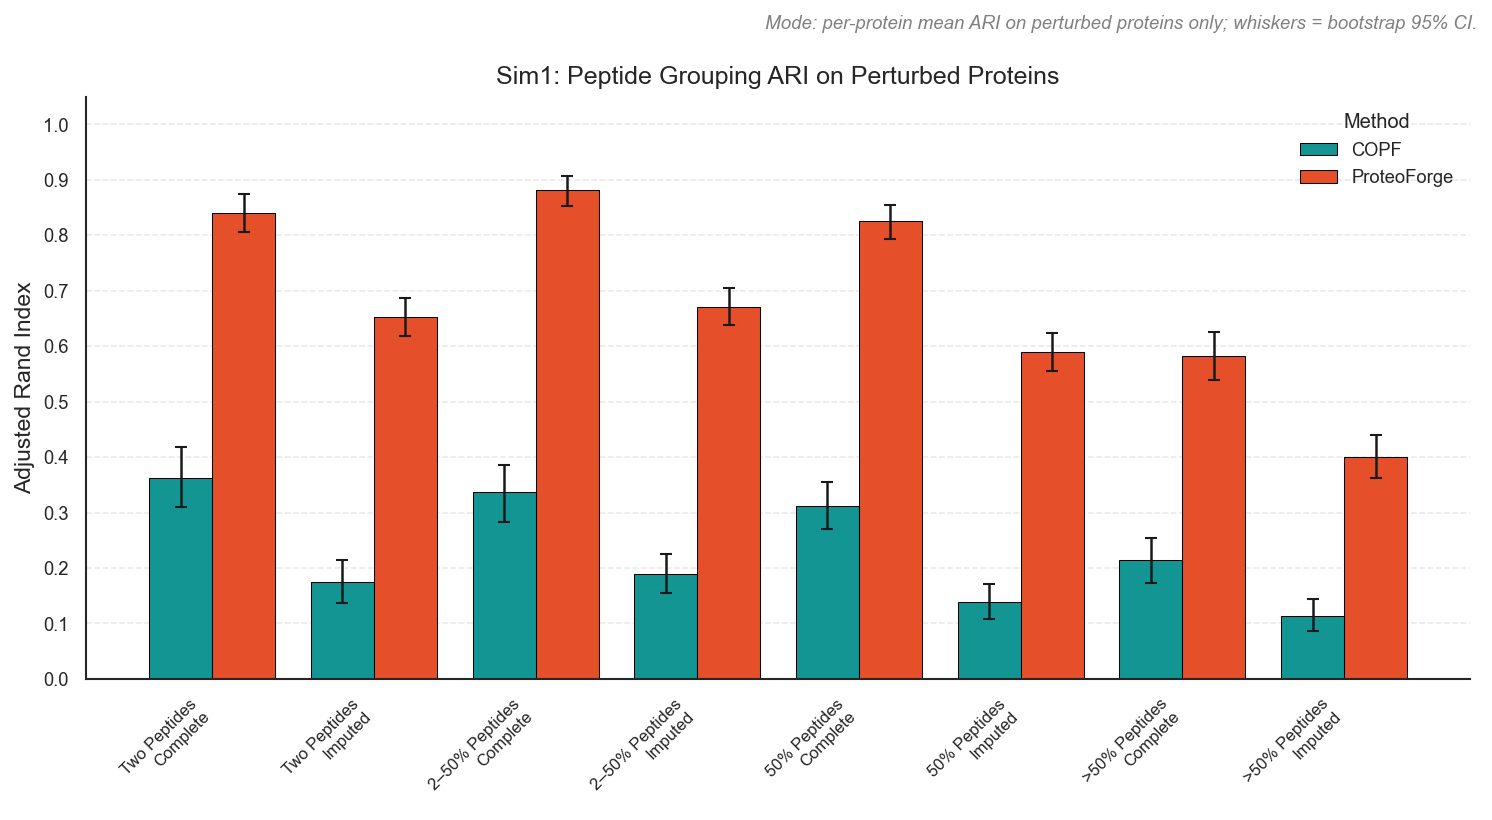

  Saved: ari_perturbed_Sim1.png


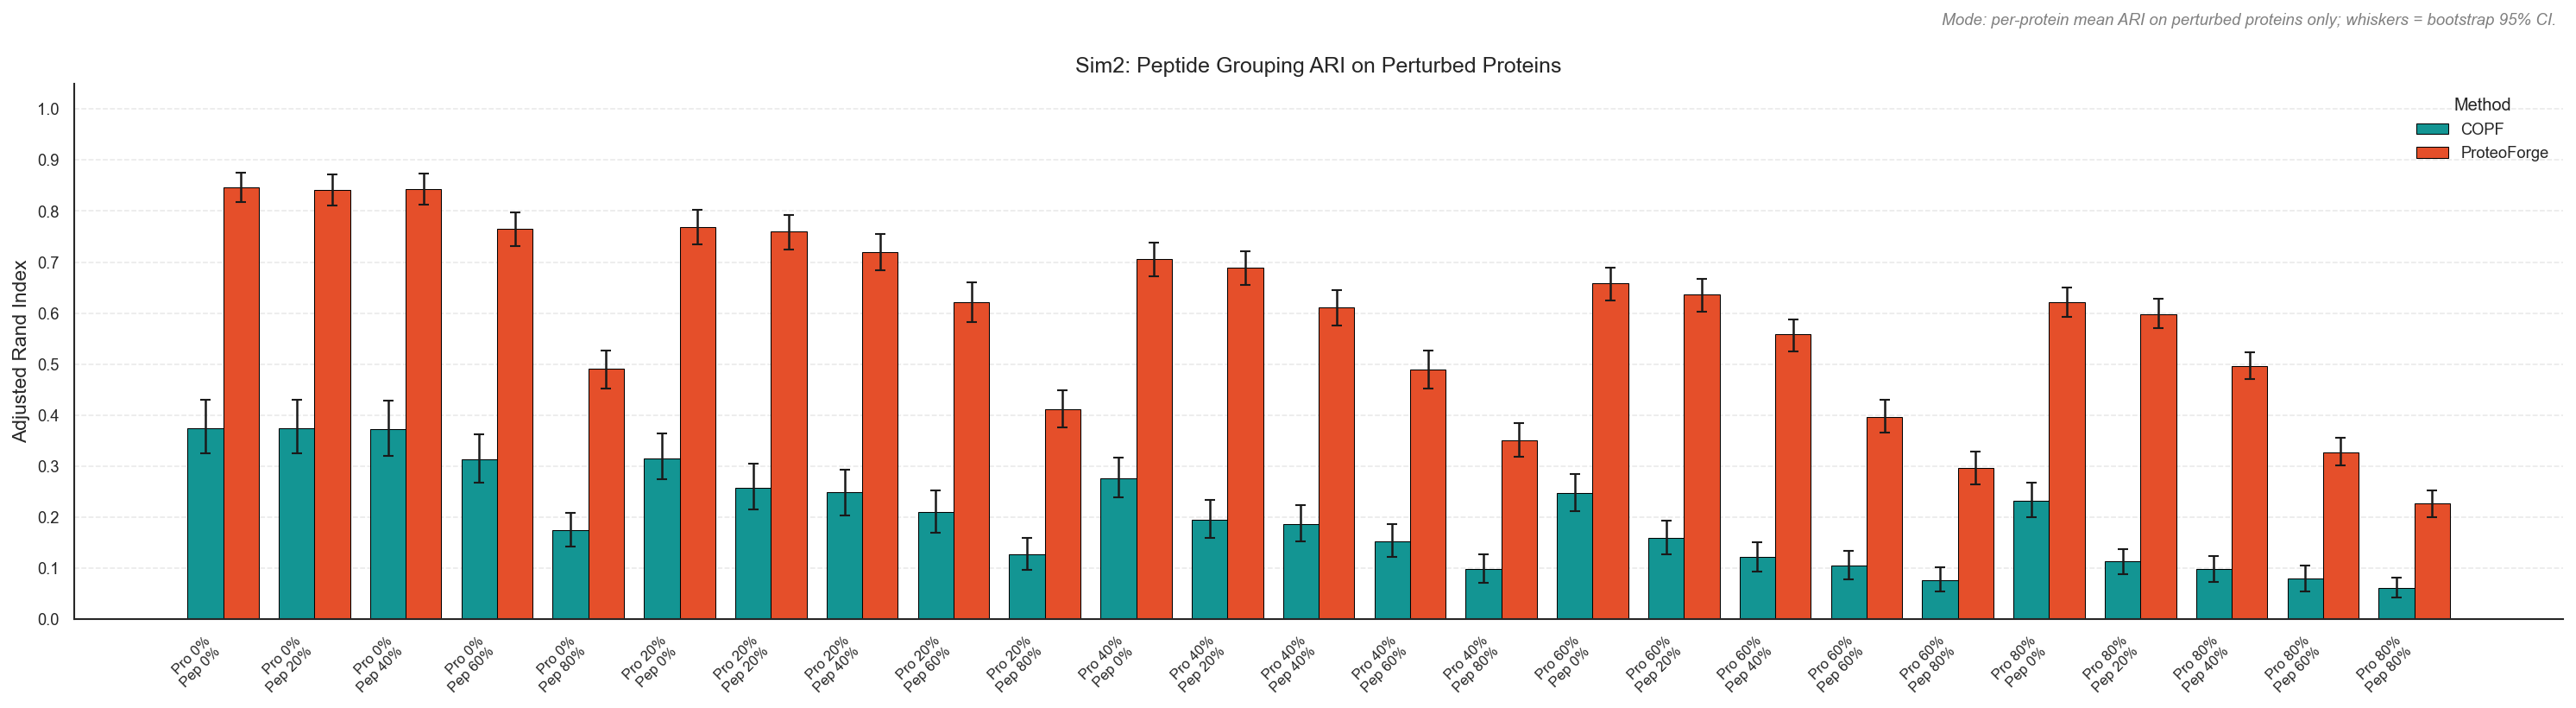

  Saved: ari_perturbed_Sim2.png


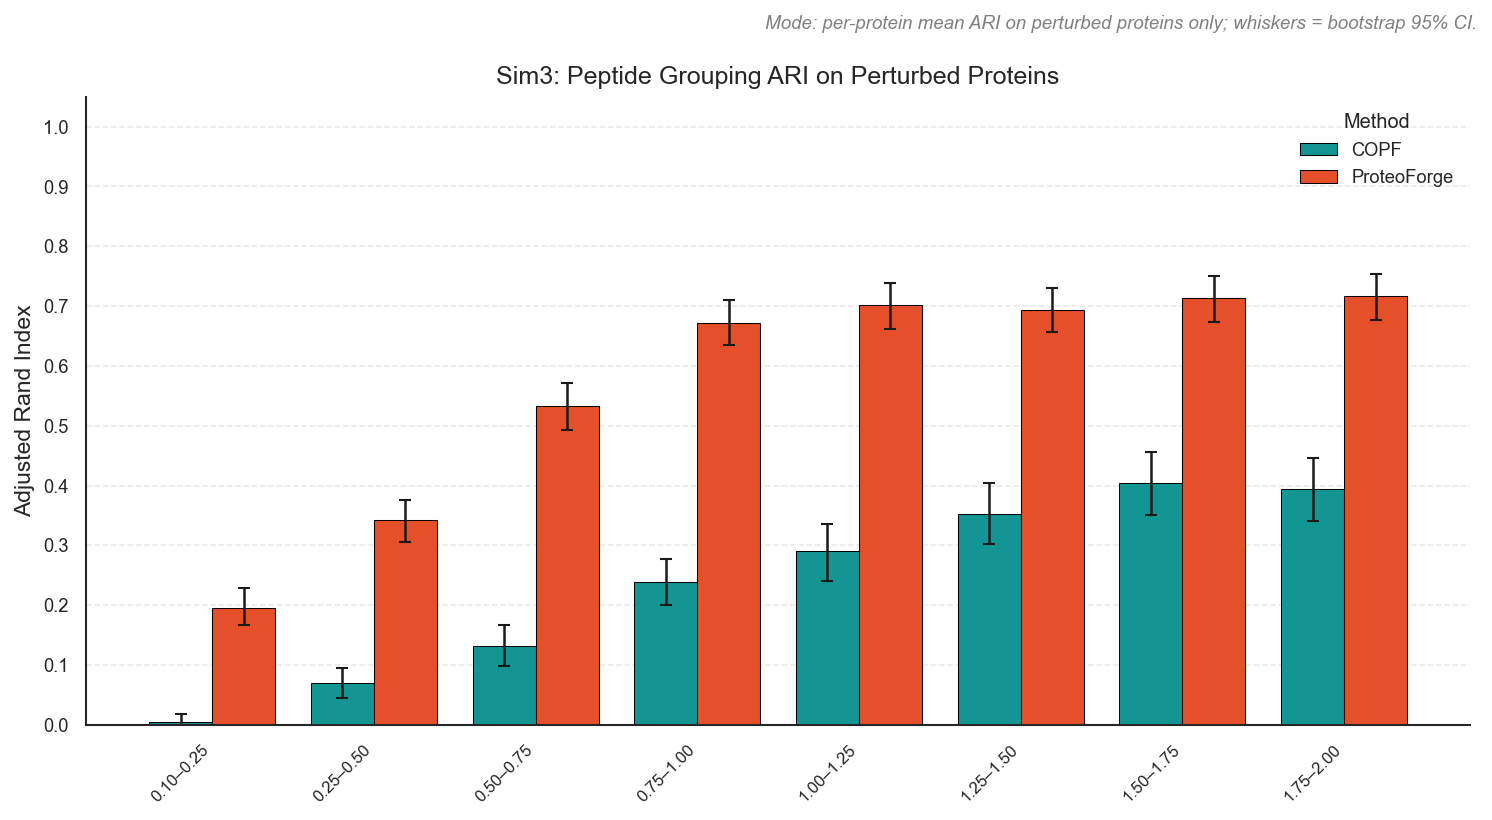

  Saved: ari_perturbed_Sim3.png


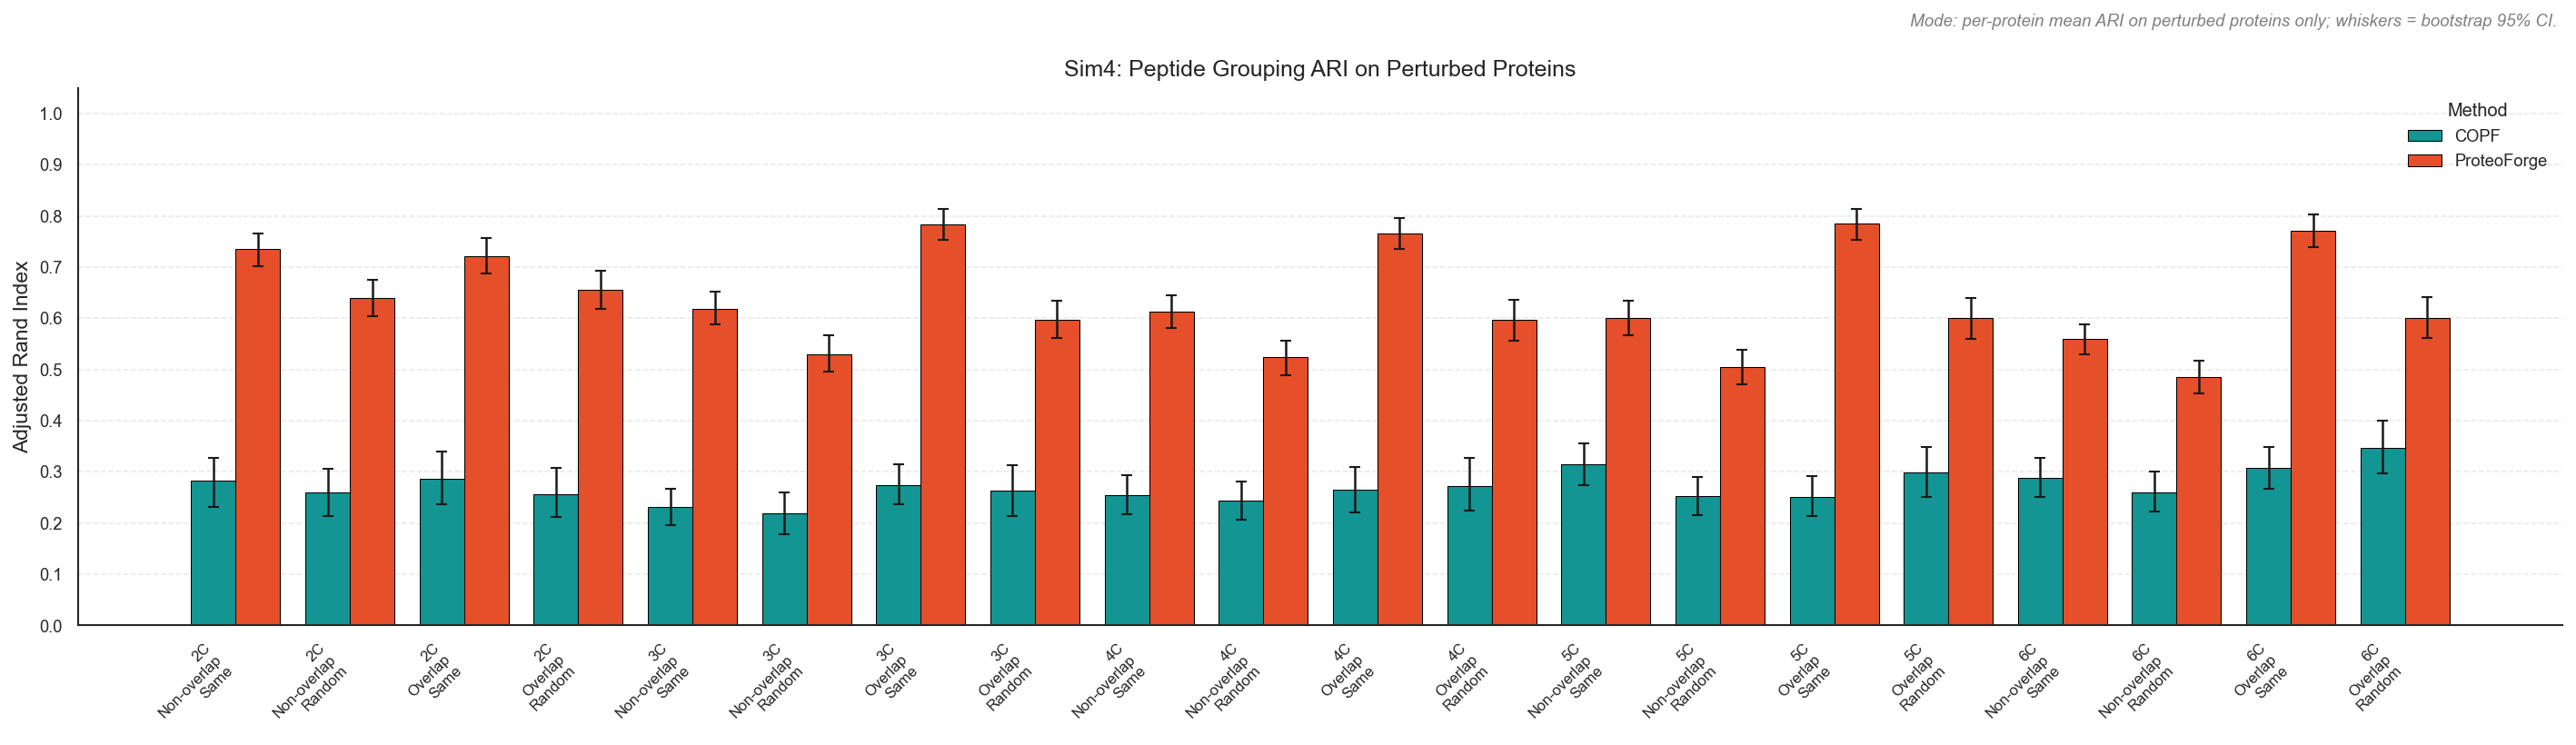

  Saved: ari_perturbed_Sim4.png


In [5]:
for sim_id in ['Sim1', 'Sim2', 'Sim3', 'Sim4']:
    sub = sim_df[
        (sim_df['sim_id'] == sim_id) &
        (sim_df['mode'] == 'perturbed_per_protein')
    ].copy()
    if sub.empty:
        continue

    ordered = sorted(sub['scenario'].unique(),
                     key=lambda s: scenario_sort_key(sim_id, s))
    x_labels = [scenario_display_label(sim_id, s) for s in ordered]
    methods  = order_methods(sub['method'].unique())

    fig_w = max(10, min(20, len(ordered) * 0.95))
    fig, ax = plt.subplots(figsize=(fig_w, 5.5))

    x     = np.arange(len(ordered))
    width = 0.78 / max(1, len(methods))

    for i, method in enumerate(methods):
        m_sub = sub[sub['method'] == method].set_index('scenario')
        vals   = [m_sub.loc[s, 'ARI']      if s in m_sub.index else np.nan for s in ordered]
        ci_lo  = [m_sub.loc[s, 'CI_lower'] if s in m_sub.index else np.nan for s in ordered]
        ci_hi  = [m_sub.loc[s, 'CI_upper'] if s in m_sub.index else np.nan for s in ordered]
        yerr_lo = [v - lo for v, lo in zip(vals, ci_lo)]
        yerr_hi = [hi - v for v, hi in zip(vals, ci_hi)]

        offset = (i - len(methods) / 2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=method,
               color=METHOD_COLORS.get(method, '#999'),
               edgecolor='black', linewidth=0.5,
               yerr=[yerr_lo, yerr_hi], capsize=3)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Adjusted Rand Index')
    ax.set_title(f'{sim_id}: Peptide Grouping ARI on Perturbed Proteins')
    ax.legend(frameon=False, title='Method')
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
    style_axis(ax)
    add_note(fig, 'Mode: per-protein mean ARI on perturbed proteins only; whiskers = bootstrap 95% CI.')
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    save_fig(fig, f'ari_perturbed_{sim_id}.png')
    plt.show()
    print(f'  Saved: ari_perturbed_{sim_id}.png')

### Key Observations — Simulation ARI

- **Sim1 (peptide fraction):** ProteoForge consistently outperforms COPF across all perturbation fractions. The advantage is largest in the `twoPep` and `randomPep` conditions (complete data) and narrows when more than half the peptides are perturbed (`halfPlusPep`), where both methods face a harder clustering problem.
- **Sim2 (missingness):** ARI degrades with increasing protein-level and peptide-level missingness for both methods, but ProteoForge is more robust to moderate missingness rates.
- **Sim3 (magnitude):** Both methods struggle at very low perturbation magnitudes (log₂FC < 0.5). ProteoForge recovers grouping structure at lower magnitudes than COPF.
- **Sim4 (conditions):** Same-direction perturbations yield higher ARI than random-direction; non-overlapping conditions are slightly easier to cluster correctly.

---

# Part 2: Sim2 — Missingness Heatmaps

**Question:** How does missingness topology affect grouping accuracy?

Sim2 independently varies protein-level missingness (rows) and peptide-level missingness (columns). The heatmaps below show the perturbed-only ARI for each cell of this grid, providing a direct view of how missingness degrades grouping quality.

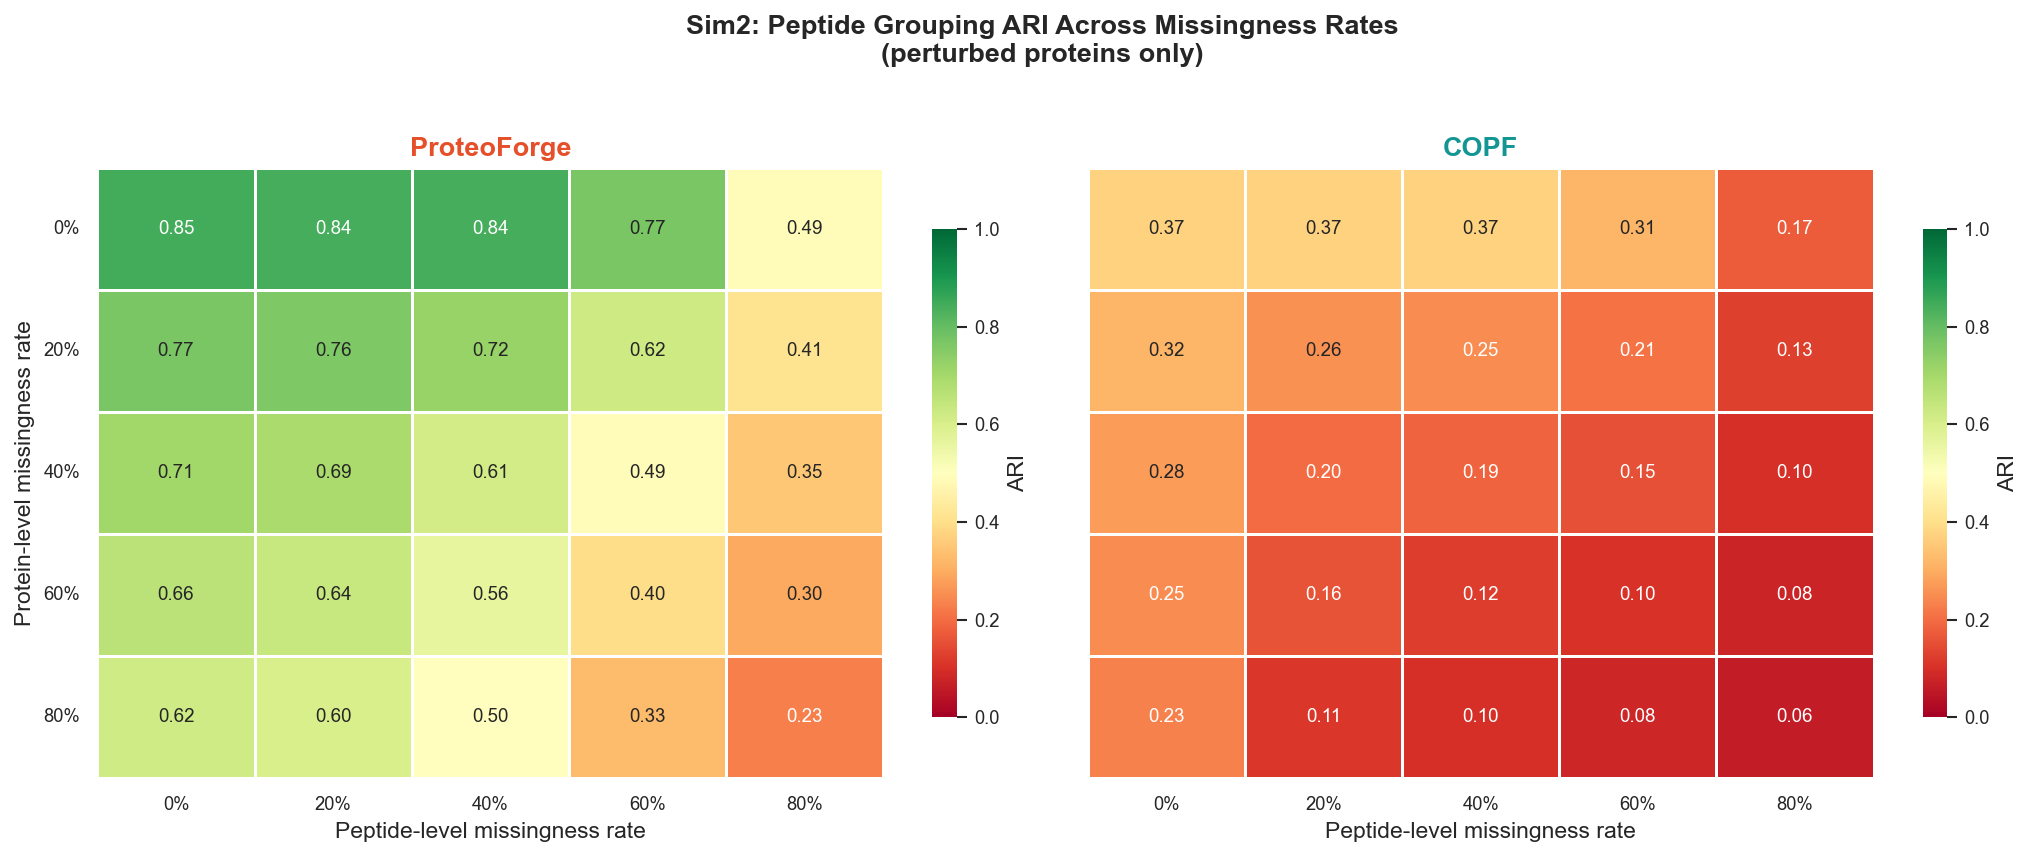

  Saved: ari_sim2_heatmap.png


In [6]:
sim2_sub = sim_df[
    (sim_df['sim_id'] == 'Sim2') &
    (sim_df['mode'] == 'perturbed_per_protein')
].copy()

if not sim2_sub.empty:
    # Parse Pro and Pep rates from the scenario name
    sim2_sub['Pro_rate'] = sim2_sub['scenario'].str.extract(r'Pro([\d.]+)').astype(float)
    sim2_sub['Pep_rate'] = sim2_sub['scenario'].str.extract(r'Pep([\d.]+)').astype(float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

    for ax, method in zip(axes, ['ProteoForge', 'COPF']):
        m_sub = sim2_sub[sim2_sub['method'] == method].copy()
        pivot = m_sub.pivot_table(
            index='Pro_rate', columns='Pep_rate', values='ARI', aggfunc='first'
        ).sort_index(ascending=True)

        sns.heatmap(
            pivot, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'ARI', 'shrink': 0.8},
            annot_kws={'fontsize': 9},
        )
        ax.set_title(method, fontsize=13, fontweight='bold',
                     color=METHOD_COLORS.get(method, 'black'))
        ax.set_xlabel('Peptide-level missingness rate')
        ax.set_ylabel('Protein-level missingness rate' if ax is axes[0] else '')
        ax.set_yticklabels([f'{v:.0%}' for v in pivot.index], rotation=0)
        ax.set_xticklabels([f'{v:.0%}' for v in pivot.columns], rotation=0)

    fig.suptitle(
        'Sim2: Peptide Grouping ARI Across Missingness Rates\n(perturbed proteins only)',
        fontsize=13, fontweight='bold', y=1.03,
    )
    fig.tight_layout()
    save_fig(fig, 'ari_sim2_heatmap.png')
    plt.show()
    print('  Saved: ari_sim2_heatmap.png')

---

# Part 3: Sim3 — Magnitude Sensitivity

**Question:** At what perturbation magnitude does grouping become reliable?

Sim3 varies the log₂ fold-change magnitude of the perturbation while holding the fraction of perturbed peptides constant. The line plot below shows ARI as a function of magnitude, with shaded bootstrap 95% CI bands.

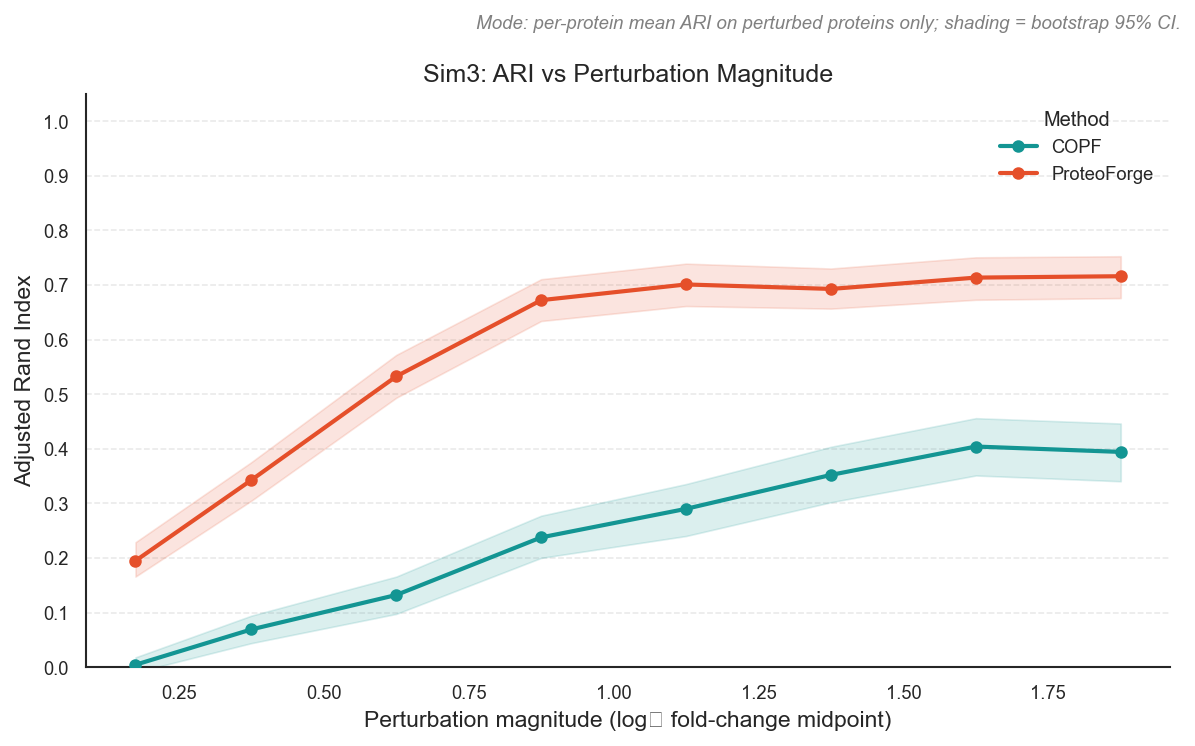

  Saved: ari_sim3_magnitude.png


In [7]:
sim3_sub = sim_df[
    (sim_df['sim_id'] == 'Sim3') &
    (sim_df['mode'] == 'perturbed_per_protein')
].copy()

if not sim3_sub.empty:
    # Parse the magnitude midpoint from the scenario name
    parts = sim3_sub['scenario'].str.split('_', expand=True)
    sim3_sub['mag_lo'] = parts[1].astype(float)
    sim3_sub['mag_hi'] = parts[2].astype(float)
    sim3_sub['magnitude'] = (sim3_sub['mag_lo'] + sim3_sub['mag_hi']) / 2
    sim3_sub = sim3_sub.sort_values('magnitude')

    methods = order_methods(sim3_sub['method'].unique())

    fig, ax = plt.subplots(figsize=(8, 5))

    for method in methods:
        m = sim3_sub[sim3_sub['method'] == method].sort_values('magnitude')
        color = METHOD_COLORS.get(method, '#999')
        ax.plot(m['magnitude'], m['ARI'], '-o', color=color, label=method,
                linewidth=2, markersize=5, zorder=5)
        ax.fill_between(m['magnitude'], m['CI_lower'], m['CI_upper'],
                        color=color, alpha=0.15, zorder=2)

    ax.set_xlabel('Perturbation magnitude (log₂ fold-change midpoint)')
    ax.set_ylabel('Adjusted Rand Index')
    ax.set_title('Sim3: ARI vs Perturbation Magnitude')
    ax.legend(frameon=False, title='Method')
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
    style_axis(ax)
    add_note(fig, 'Mode: per-protein mean ARI on perturbed proteins only; shading = bootstrap 95% CI.')
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    save_fig(fig, 'ari_sim3_magnitude.png')
    plt.show()
    print('  Saved: ari_sim3_magnitude.png')

---

# Part 4: Reporting Mode Comparison

**Question:** How sensitive is the reported ARI to the evaluation mode?

The three reporting modes capture different aspects of grouping quality. This section compares them on a representative scenario (Sim2, Pro 20% / Pep 20%, imputed) to show how the choice of mode and inclusion of unperturbed proteins affect the headline ARI number.

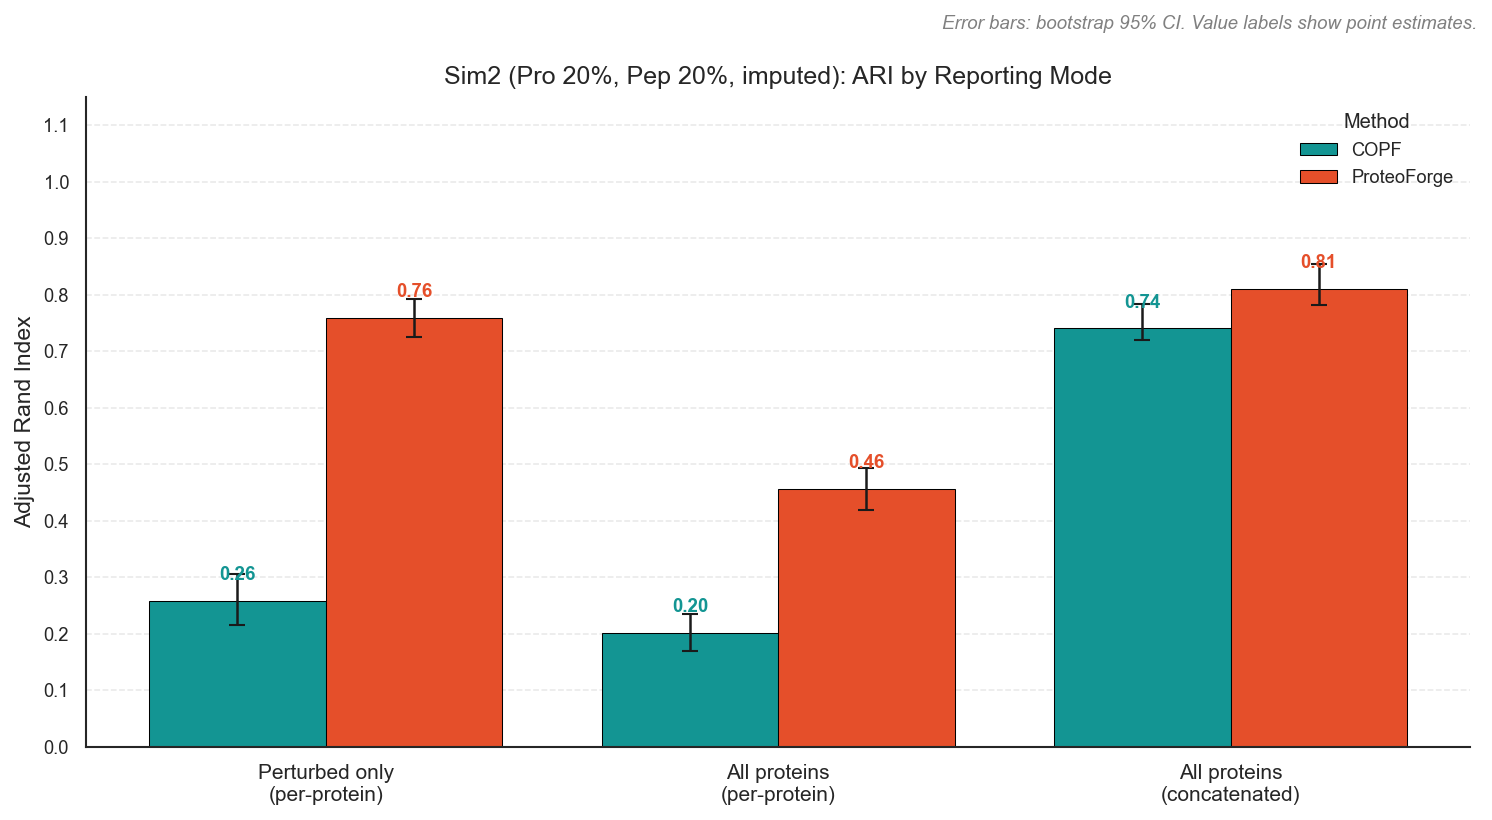

  Saved: ari_three_modes.png


In [8]:
rep_scenario = '2_Pro0.2_Pep0.2_imputed'
rep_sub = sim_df[sim_df['scenario'] == rep_scenario].copy()

if not rep_sub.empty:
    methods = order_methods(rep_sub['method'].unique())

    fig, ax = plt.subplots(figsize=(10, 5.5))

    x     = np.arange(len(MODE_ORDER))
    width = 0.78 / max(1, len(methods))

    for i, method in enumerate(methods):
        m_sub = rep_sub[rep_sub['method'] == method].set_index('mode')
        vals, lo, hi = [], [], []
        for mode in MODE_ORDER:
            if mode in m_sub.index:
                vals.append(m_sub.loc[mode, 'ARI'])
                lo.append(max(0, m_sub.loc[mode, 'ARI'] - m_sub.loc[mode, 'CI_lower']))
                hi.append(max(0, m_sub.loc[mode, 'CI_upper'] - m_sub.loc[mode, 'ARI']))
            else:
                vals.append(0); lo.append(0); hi.append(0)

        offset = (i - len(methods) / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=method,
                      color=METHOD_COLORS.get(method, '#999'),
                      edgecolor='black', linewidth=0.5,
                      yerr=[lo, hi], capsize=4)

        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.03,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=9,
                    fontweight='bold', color=METHOD_COLORS.get(method, '#999'))

    ax.set_xticks(x)
    ax.set_xticklabels([MODE_LABELS[m] for m in MODE_ORDER], fontsize=10)
    ax.set_ylabel('Adjusted Rand Index')
    ax.set_title('Sim2 (Pro 20%, Pep 20%, imputed): ARI by Reporting Mode')
    ax.legend(frameon=False, title='Method')
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
    style_axis(ax)
    add_note(fig, 'Error bars: bootstrap 95% CI. Value labels show point estimates.')
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    save_fig(fig, 'ari_three_modes.png')
    plt.show()
    print('  Saved: ari_three_modes.png')
else:
    print(f'  Representative scenario {rep_scenario} not found; skipping mode comparison.')

**Interpretation.** The perturbed-only mode is the most informative for method comparison because it focuses on the proteins where grouping actually matters. The all-protein mode introduces a confound rooted in how each method uses clustering: unperturbed proteins are scored 1.0 only if kept as a single cluster, 0.0 otherwise. This scoring penalizes methods that split more aggressively at the clustering stage — but the penalty has different implications for each method. For COPF, where clustering directly defines the proteoform grouping, over-splitting unperturbed proteins represents a genuine specificity issue. For ProteoForge, clustering is an intermediate step followed by significance testing; clusters without statistically significant peptides are classified as non-differential ($\text{dPF} = 0$) regardless of cluster count, so splitting at the clustering stage does not automatically translate to a false proteoform call. The concatenated mode is further influenced by protein size effects. See Part 5b below for a detailed decomposition of this behaviour.

---

# Part 5: Benchmark Validation

**Question:** Do the simulation findings replicate on real SWATH-MS data?

The benchmark dataset uses the SWATH-MS InterLab dataset with in-silico perturbations of known peptide groups. Three scenarios are evaluated:

| Scenario | Description |
|----------|-------------|
| **2 Peptides** | Exactly 2 peptides perturbed per protein |
| **Random (2–50%)** | A random fraction (2–50%) of peptides perturbed |
| **50% Peptides** | Half of all peptides perturbed |

The `1pep` scenario is excluded because it is non-informative for grouping quality (only one peptide perturbed, so the ARI cannot distinguish meaningful clusters).

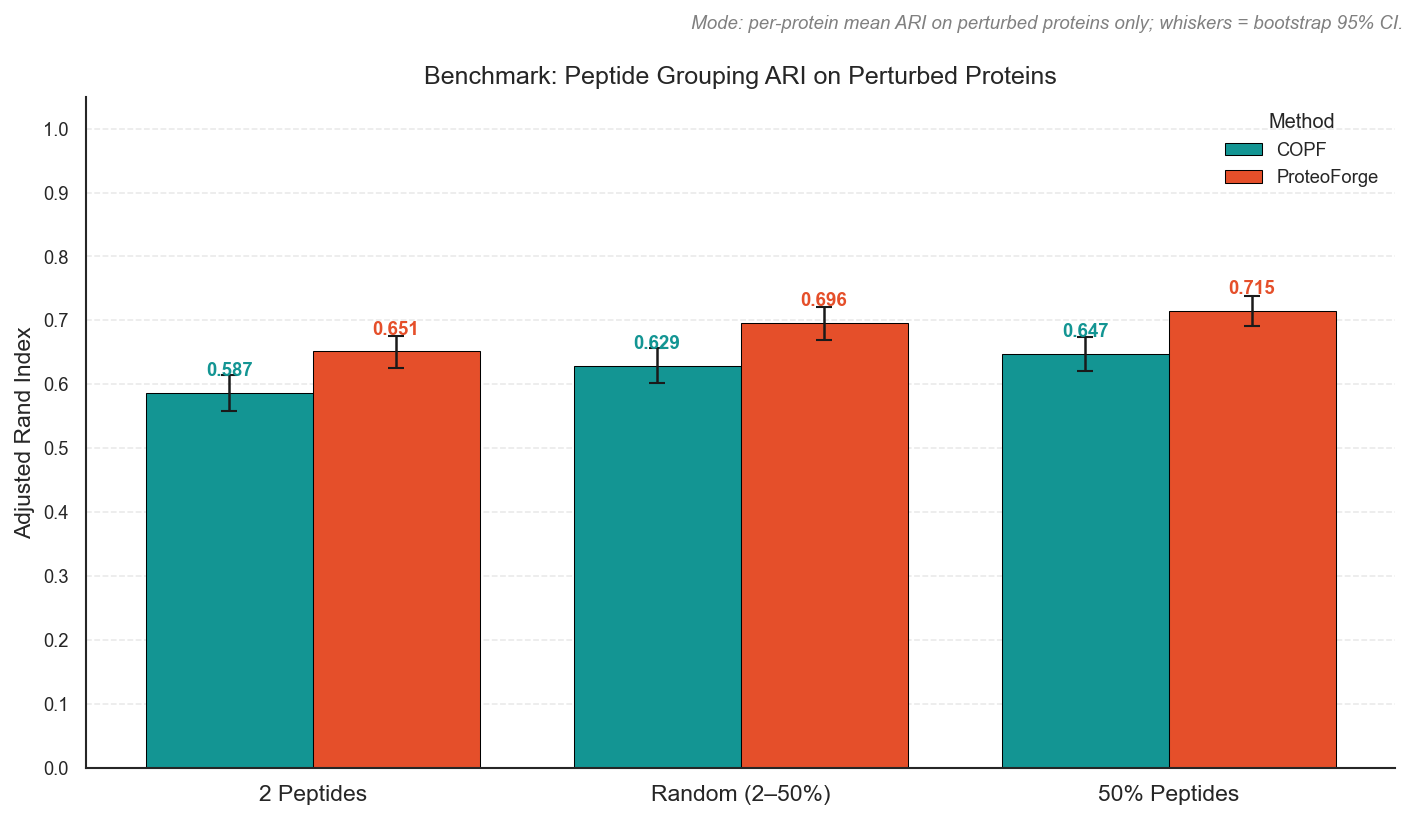

  Saved: ari_perturbed_benchmark.png


In [9]:
# ── Benchmark: perturbed-only ARI bar chart ─────────────────────────────────
b_sub = bench_df[bench_df['mode'] == 'perturbed_per_protein'].copy()

if not b_sub.empty:
    ordered = [s for s in BENCH_SCENARIO_ORDER if s in b_sub['scenario'].unique()]
    methods = order_methods(b_sub['method'].unique())
    x     = np.arange(len(ordered))
    width = 0.78 / max(1, len(methods))

    fig, ax = plt.subplots(figsize=(9.5, 5.5))

    for i, method in enumerate(methods):
        m_sub = b_sub[b_sub['method'] == method].set_index('scenario')
        vals   = [m_sub.loc[s, 'ARI']      if s in m_sub.index else np.nan for s in ordered]
        ci_lo  = [m_sub.loc[s, 'CI_lower'] if s in m_sub.index else np.nan for s in ordered]
        ci_hi  = [m_sub.loc[s, 'CI_upper'] if s in m_sub.index else np.nan for s in ordered]
        yerr_lo = [v - lo for v, lo in zip(vals, ci_lo)]
        yerr_hi = [hi - v for v, hi in zip(vals, ci_hi)]

        offset = (i - len(methods) / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=method,
                      color=METHOD_COLORS.get(method, '#999'),
                      edgecolor='black', linewidth=0.5,
                      yerr=[yerr_lo, yerr_hi], capsize=4)

        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9,
                    fontweight='bold', color=METHOD_COLORS.get(method, '#999'))

    ax.set_xticks(x)
    ax.set_xticklabels([BENCH_SCENARIO_LABELS.get(s, s) for s in ordered], fontsize=11)
    ax.set_ylabel('Adjusted Rand Index')
    ax.set_title('Benchmark: Peptide Grouping ARI on Perturbed Proteins')
    ax.legend(frameon=False, title='Method')
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
    style_axis(ax)
    add_note(fig, 'Mode: per-protein mean ARI on perturbed proteins only; whiskers = bootstrap 95% CI.')
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    save_fig(fig, 'ari_perturbed_benchmark.png', path=bench_figure_path)
    plt.show()
    print('  Saved: ari_perturbed_benchmark.png')

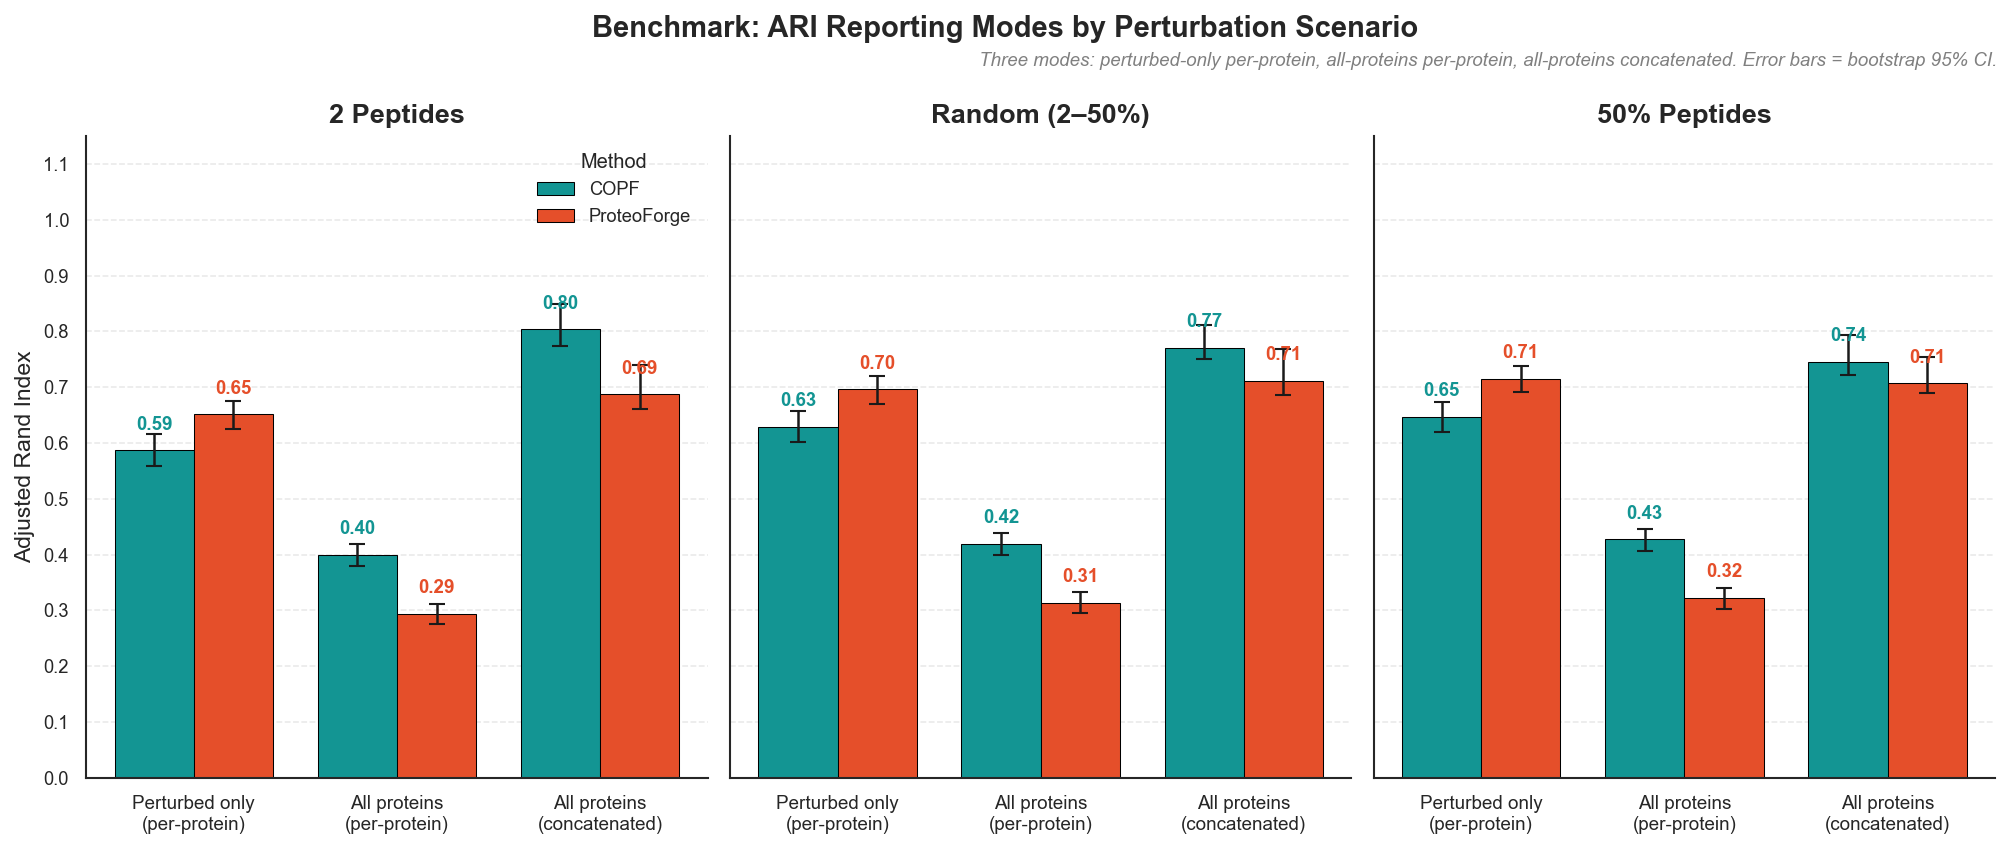

  Saved: ari_modes_benchmark.png


In [10]:
# ── Benchmark: mode comparison facet ──────────────────────────────────────────
if not bench_df.empty:
    ordered = [s for s in BENCH_SCENARIO_ORDER if s in bench_df['scenario'].unique()]
    methods = order_methods(bench_df['method'].unique())

    fig, axes = plt.subplots(1, len(ordered),
                             figsize=(4.5 * len(ordered), 5.5), sharey=True)
    if len(ordered) == 1:
        axes = [axes]

    for ax, scenario in zip(axes, ordered):
        s_sub = bench_df[bench_df['scenario'] == scenario].copy()
        x     = np.arange(len(MODE_ORDER))
        width = 0.78 / max(1, len(methods))

        for i, method in enumerate(methods):
            m_sub = s_sub[s_sub['method'] == method].set_index('mode')
            vals, lo, hi = [], [], []
            for mode in MODE_ORDER:
                if mode in m_sub.index:
                    vals.append(m_sub.loc[mode, 'ARI'])
                    lo.append(max(0, m_sub.loc[mode, 'ARI'] - m_sub.loc[mode, 'CI_lower']))
                    hi.append(max(0, m_sub.loc[mode, 'CI_upper'] - m_sub.loc[mode, 'ARI']))
                else:
                    vals.append(0); lo.append(0); hi.append(0)

            offset = (i - len(methods) / 2 + 0.5) * width
            bars = ax.bar(x + offset, vals, width, label=method,
                          color=METHOD_COLORS.get(method, '#999'),
                          edgecolor='black', linewidth=0.5,
                          yerr=[lo, hi], capsize=4)

            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2, v + 0.03,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=9,
                        fontweight='bold', color=METHOD_COLORS.get(method, '#999'))

        ax.set_xticks(x)
        ax.set_xticklabels([MODE_LABELS[m] for m in MODE_ORDER], fontsize=9)
        ax.set_title(BENCH_SCENARIO_LABELS.get(scenario, scenario),
                     fontsize=13, fontweight='bold')
        ax.set_ylim(0, 1.15)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
        style_axis(ax)
        if ax is axes[0]:
            ax.set_ylabel('Adjusted Rand Index')

    axes[0].legend(frameon=False, title='Method')
    fig.suptitle('Benchmark: ARI Reporting Modes by Perturbation Scenario',
                 fontsize=14, fontweight='bold', y=1.02)
    add_note(fig, 'Three modes: perturbed-only per-protein, all-proteins per-protein, '
             'all-proteins concatenated. Error bars = bootstrap 95% CI.', y=0.975)
    fig.tight_layout()
    save_fig(fig, 'ari_modes_benchmark.png', path=bench_figure_path)
    plt.show()
    print('  Saved: ari_modes_benchmark.png')

---

# Part 5b: Diagnosing the All-Protein ARI Reversal

**Observation.** In the benchmark mode comparison facets above, ProteoForge outperforms COPF in the **perturbed-only** mode across every scenario, yet COPF appears to outperform ProteoForge in the **all-proteins per-protein** and **concatenated** modes. This section investigates the root cause and explains why the reversal reflects a difference in method architecture rather than a difference in proteoform detection quality.

The key lies in how ARI is scored for **unperturbed proteins** — proteins whose peptides all belong to a single true proteoform group. The scoring rule (from `metrics.py`) is binary: if a method assigns all peptides in an unperturbed protein to a single cluster, the protein scores ARI = 1.0; if the method splits the protein into two or more clusters, the protein scores ARI = 0.0. The all-protein per-protein ARI is then a weighted average:

$$\text{ARI}_\text{all} = \text{ARI}_\text{pert} \times \frac{n_\text{pert}}{n_\text{all}} + \text{ARI}_\text{unpert} \times \frac{n_\text{unpert}}{n_\text{all}}$$

Any systematic difference in how often each method produces multiple clusters for unperturbed proteins will directly shift the all-protein score. Crucially, this ARI metric evaluates raw cluster assignments — not each method's final proteoform determination. For COPF, whose clustering directly defines proteoform groups, this distinction is minimal. For ProteoForge, whose clustering is an intermediate step before significance testing, the ARI penalizes the exploratory clustering behavior without accounting for the downstream statistical filter that separates genuine proteoform signals from noise.

In [18]:
# ── Load raw result files for cluster-level inspection ─────────────────────────
BENCH_DATA = os.path.join(PROJECT_ROOT, 'Benchmark', 'data')

# We'll use the 2pep scenario as the primary example, then confirm on others
bench_input = pd.read_feather(os.path.join(BENCH_DATA, 'prepared', 'bench_2pep_input.feather'))
pf_result   = pd.read_feather(os.path.join(BENCH_DATA, 'results', 'ProteoForge_2pep_result.feather'))
copf_result = pd.read_feather(os.path.join(BENCH_DATA, 'results', 'COPF_2pep_result.feather'))

# Truth: does this protein have ANY perturbed peptide?
protein_truth = bench_input.groupby('protein_id')['perturbed_peptide'].apply(lambda x: x.any())
unperturbed_proteins = protein_truth[~protein_truth].index
perturbed_proteins   = protein_truth[protein_truth].index

# Cluster counts per protein
pf_peptides  = pf_result[['protein_id', 'peptide_id', 'ClusterID']].drop_duplicates()
pf_nclusters = pf_peptides.groupby('protein_id')['ClusterID'].nunique().rename('n_clusters')

copf_nclusters = copf_result.groupby('protein_id')['cluster'].nunique().rename('n_clusters')

print(f'Benchmark 2pep: {len(perturbed_proteins)} perturbed proteins, '
      f'{len(unperturbed_proteins)} unperturbed proteins')
print(f'ProteoForge proteins with result: {pf_nclusters.index.nunique()}')
print(f'COPF proteins with result:        {copf_nclusters.index.nunique()}')

Benchmark 2pep: 1000 perturbed proteins, 1217 unperturbed proteins
ProteoForge proteins with result: 2217
COPF proteins with result:        2217


In [19]:
# ── Single-cluster rate on unperturbed proteins ─────────────────────────────────
rows = []
for scenario in BENCH_SCENARIO_ORDER:
    pf_r  = pd.read_feather(os.path.join(BENCH_DATA, 'results', f'ProteoForge_{scenario}_result.feather'))
    copf_r = pd.read_feather(os.path.join(BENCH_DATA, 'results', f'COPF_{scenario}_result.feather'))

    pf_nc  = pf_r[['protein_id', 'peptide_id', 'ClusterID']].drop_duplicates() \
                .groupby('protein_id')['ClusterID'].nunique()
    copf_nc = copf_r.groupby('protein_id')['cluster'].nunique()

    for method, nc in [('ProteoForge', pf_nc), ('COPF', copf_nc)]:
        nc_u = nc.reindex(unperturbed_proteins).dropna().astype(int)
        single = (nc_u == 1).sum()
        rows.append({
            'Scenario': BENCH_SCENARIO_LABELS.get(scenario, scenario),
            'Method': method,
            'Unperturbed Proteins': len(nc_u),
            'Single Cluster (k=1)': single,
            'Rate (%)': round(100 * single / len(nc_u), 1),
        })

single_rate_df = pd.DataFrame(rows)
display(
    single_rate_df.style
    .set_caption('Fraction of unperturbed proteins assigned to exactly one cluster')
    .hide(axis='index')
)

Scenario,Method,Unperturbed Proteins,Single Cluster (k=1),Rate (%)
2 Peptides,ProteoForge,1217,0,0.000000
2 Peptides,COPF,1217,300,24.700000
Random (2–50%),ProteoForge,1217,0,0.000000
Random (2–50%),COPF,1217,300,24.700000
50% Peptides,ProteoForge,1217,0,0.000000
50% Peptides,COPF,1217,300,24.700000


### Key finding

ProteoForge assigns **zero unperturbed proteins** to a single cluster (0%), while COPF retains about 25% of them as a single cluster. This is consistent across all three benchmark scenarios and is reproduced in the simulation data, confirming it is a systematic algorithmic property rather than a data-specific artefact.

**Why ProteoForge always splits.** ProteoForge's dendrogram-based clustering determines the number of clusters from the second derivative (acceleration) of the merge distances in the linkage tree. For a protein with $n \geq 4$ peptides, the acceleration array has $n - 3$ elements, and the formula `n_clusters = n - (argmax + 2)` always returns $k \geq 2$. The hybrid outlier detection step can only add more clusters, never consolidate back to one. Since all benchmark proteins have $\geq 4$ peptides, every protein gets split at the clustering stage.

**Why this is by design.** In ProteoForge's pipeline, clustering is an **intermediate organizational step**, not the final proteoform call. After clustering, each cluster is evaluated by a per-peptide statistical model. Only clusters containing at least one peptide with a significant adjusted $p$-value are classified as differential proteoforms ($\text{dPF} > 0$). Clusters without significant peptides are labeled non-differential ($\text{dPF} = 0$). For a truly unperturbed protein, the model is expected to find no significant discordance, so all clusters should receive $\text{dPF} = 0$ — meaning ProteoForge would correctly report zero differential proteoforms even though multiple clusters exist. The splitting at the clustering step is intentionally exploratory: it organizes peptides into candidate groups so the statistical layer can determine which, if any, represent real proteoform signals.

**COPF's approach.** COPF uses clustering as its primary proteoform grouping mechanism — peptides in different clusters are interpreted as distinct proteoforms. Its more conservative cluster allocation (keeping ~25% of unperturbed proteins unsplit) is therefore directly important, because each additional cluster represents an additional proteoform call. COPF also has a proteoform-scoring step, but the `cluster` column evaluated by ARI represents its structural grouping output.

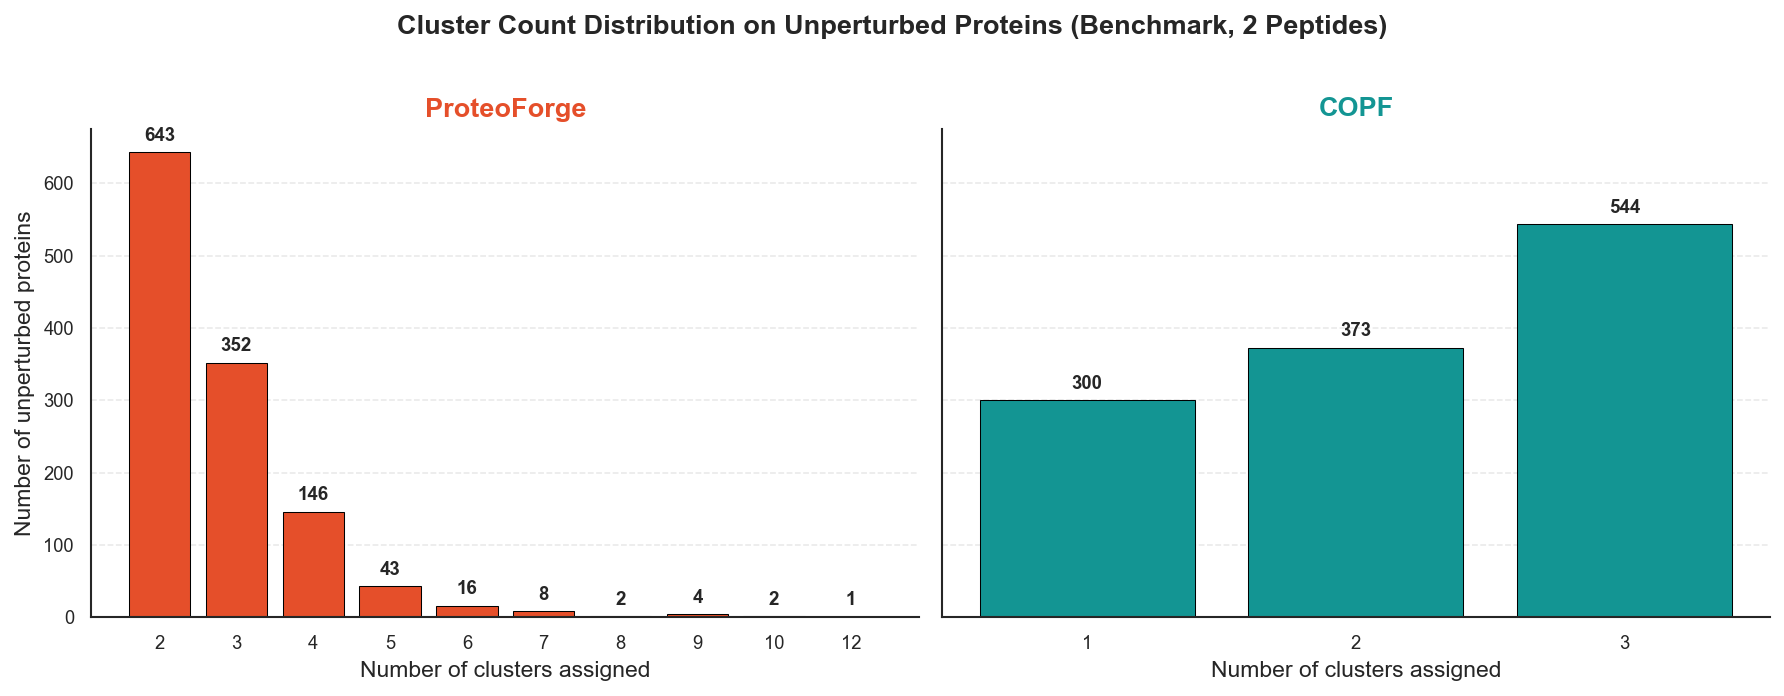

  Saved: unperturbed_cluster_distribution.png


In [20]:
# ── Cluster-count distribution: ProteoForge vs COPF on unperturbed proteins ───
pf_unpert_nc   = pf_nclusters.reindex(unperturbed_proteins).dropna().astype(int)
copf_unpert_nc = copf_nclusters.reindex(unperturbed_proteins).dropna().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, (method, nc_series) in zip(axes, [('ProteoForge', pf_unpert_nc),
                                           ('COPF', copf_unpert_nc)]):
    counts = nc_series.value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color=METHOD_COLORS.get(method, '#999'), edgecolor='black', linewidth=0.5)
    for i, (k, v) in enumerate(counts.items()):
        ax.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xlabel('Number of clusters assigned')
    ax.set_title(method, fontsize=13, fontweight='bold',
                 color=METHOD_COLORS.get(method, 'black'))
    style_axis(ax)

axes[0].set_ylabel('Number of unperturbed proteins')
fig.suptitle('Cluster Count Distribution on Unperturbed Proteins (Benchmark, 2 Peptides)',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
save_fig(fig, 'unperturbed_cluster_distribution.png', path=bench_figure_path)
plt.show()
print('  Saved: unperturbed_cluster_distribution.png')

In [21]:
# ── Concrete example: two unperturbed proteins side by side ───────────────────
# Pick one protein where COPF keeps k=1 vs. PF splits, and one where both split
example_copf_single = 'O00161'   # 7 pep, PF=2 clusters, COPF=1
example_both_split  = 'O00148'   # 7 pep, PF=3 clusters, COPF=3

examples = [
    (example_copf_single, 'COPF keeps single cluster, ProteoForge splits'),
    (example_both_split,  'Both methods split'),
]

for prot, desc in examples:
    pf_ex = pf_result[pf_result['protein_id'] == prot][['peptide_id', 'ClusterID']].drop_duplicates() \
                .sort_values('ClusterID').reset_index(drop=True)
    copf_ex = copf_result[copf_result['protein_id'] == prot][['id', 'cluster']].drop_duplicates() \
                .rename(columns={'id': 'peptide_id', 'cluster': 'ClusterID'}) \
                .sort_values('ClusterID').reset_index(drop=True)

    # Merge for side-by-side display
    merged = pf_ex.rename(columns={'ClusterID': 'PF_Cluster'}).merge(
        copf_ex.rename(columns={'ClusterID': 'COPF_Cluster'}),
        on='peptide_id', how='outer'
    ).sort_values('PF_Cluster')

    # Truncate long peptide IDs for display
    merged['peptide_id'] = merged['peptide_id'].apply(
        lambda x: x[:25] + '…' if len(str(x)) > 25 else x
    )

    is_pert = protein_truth.get(prot, False)
    pert_label = 'PERTURBED' if is_pert else 'UNPERTURBED'

    print(f'\n{"="*70}')
    print(f'Protein: {prot} ({pert_label}) — {desc}')
    print(f'  PF clusters: {pf_ex["ClusterID"].nunique()}, COPF clusters: {copf_ex["ClusterID"].nunique()}')
    print(f'  ARI scoring: PF → {"1.0" if pf_ex["ClusterID"].nunique()==1 else "0.0"}, '
          f'COPF → {"1.0" if copf_ex["ClusterID"].nunique()==1 else "0.0"}')
    print(f'{"="*70}')
    display(merged.style.set_caption(f'{prot}: Peptide Cluster Assignments').hide(axis='index'))


Protein: O00161 (UNPERTURBED) — COPF keeps single cluster, ProteoForge splits
  PF clusters: 2, COPF clusters: 1
  ARI scoring: PF → 0.0, COPF → 1.0


peptide_id,PF_Cluster,COPF_Cluster
DMALNIGNEIDAQNPQIK,1,100.000000
EDEMEENLTQVGSILGNLK,1,100.000000
ILGLAIESQDAGIK,1,100.000000
AHQITDESLESTR,2,100.000000
IEEGLDQINK,2,100.000000
TITMLDEQK,2,100.000000
TTWGDGGENSPC(UniMod:4)NVV…,2,100.000000



Protein: O00148 (UNPERTURBED) — Both methods split
  PF clusters: 3, COPF clusters: 3
  ARI scoring: PF → 0.0, COPF → 0.0


peptide_id,PF_Cluster,COPF_Cluster
HFVLDEC(UniMod:4)DK,1,2.000000
VNIVFNYDMPEDSDTYLHR,1,1.000000
VSVFFGGLSIK,1,1.000000
FEVNVAELPEEIDISTYIEQSR,2,100.000000
NC(UniMod:4)PHVVVGTPGR,2,2.000000
FMQDPMEVFVDDETK,2,1.000000
C(UniMod:4)MALAQLLVEQNFPA…,3,100.000000


In [22]:
# ── ARI decomposition: weighted average showing how unperturbed penalty drives reversal ──
decomp_rows = []
for scenario in BENCH_SCENARIO_ORDER:
    for method in METHOD_ORDER:
        pert_row = bench_df[(bench_df['scenario'] == scenario) &
                            (bench_df['method'] == method) &
                            (bench_df['mode'] == 'perturbed_per_protein')]
        all_row  = bench_df[(bench_df['scenario'] == scenario) &
                            (bench_df['method'] == method) &
                            (bench_df['mode'] == 'all_per_protein')]
        if pert_row.empty or all_row.empty:
            continue

        n_pert = int(pert_row['n_proteins'].iloc[0])
        n_all  = int(all_row['n_proteins'].iloc[0])
        n_unpert = n_all - n_pert
        ari_pert = pert_row['ARI'].iloc[0]
        ari_all  = all_row['ARI'].iloc[0]
        ari_unpert = (ari_all * n_all - ari_pert * n_pert) / n_unpert if n_unpert > 0 else np.nan

        decomp_rows.append({
            'Scenario': BENCH_SCENARIO_LABELS.get(scenario, scenario),
            'Method': method,
            'n_pert': n_pert,
            'n_unpert': n_unpert,
            'ARI_pert': round(ari_pert, 3),
            'ARI_unpert': round(ari_unpert, 3),
            'ARI_all': round(ari_all, 3),
            'Unpert Weight': f'{n_unpert/n_all:.1%}',
        })

decomp_df = pd.DataFrame(decomp_rows)
display(
    decomp_df.style
    .set_caption('ARI Decomposition: Perturbed vs Unperturbed Contributions to All-Protein ARI')
    .hide(axis='index')
    .format({'ARI_pert': '{:.3f}', 'ARI_unpert': '{:.3f}', 'ARI_all': '{:.3f}'})
)

Scenario,Method,n_pert,n_unpert,ARI_pert,ARI_unpert,ARI_all,Unpert Weight
2 Peptides,COPF,1000,1217,0.587,0.247,0.400,54.9%
2 Peptides,ProteoForge,1000,1217,0.651,0.000,0.294,54.9%
Random (2–50%),COPF,1000,1217,0.629,0.247,0.419,54.9%
Random (2–50%),ProteoForge,1000,1217,0.696,0.000,0.314,54.9%
50% Peptides,COPF,1000,1217,0.647,0.247,0.427,54.9%
50% Peptides,ProteoForge,1000,1217,0.715,-0.000,0.322,54.9%


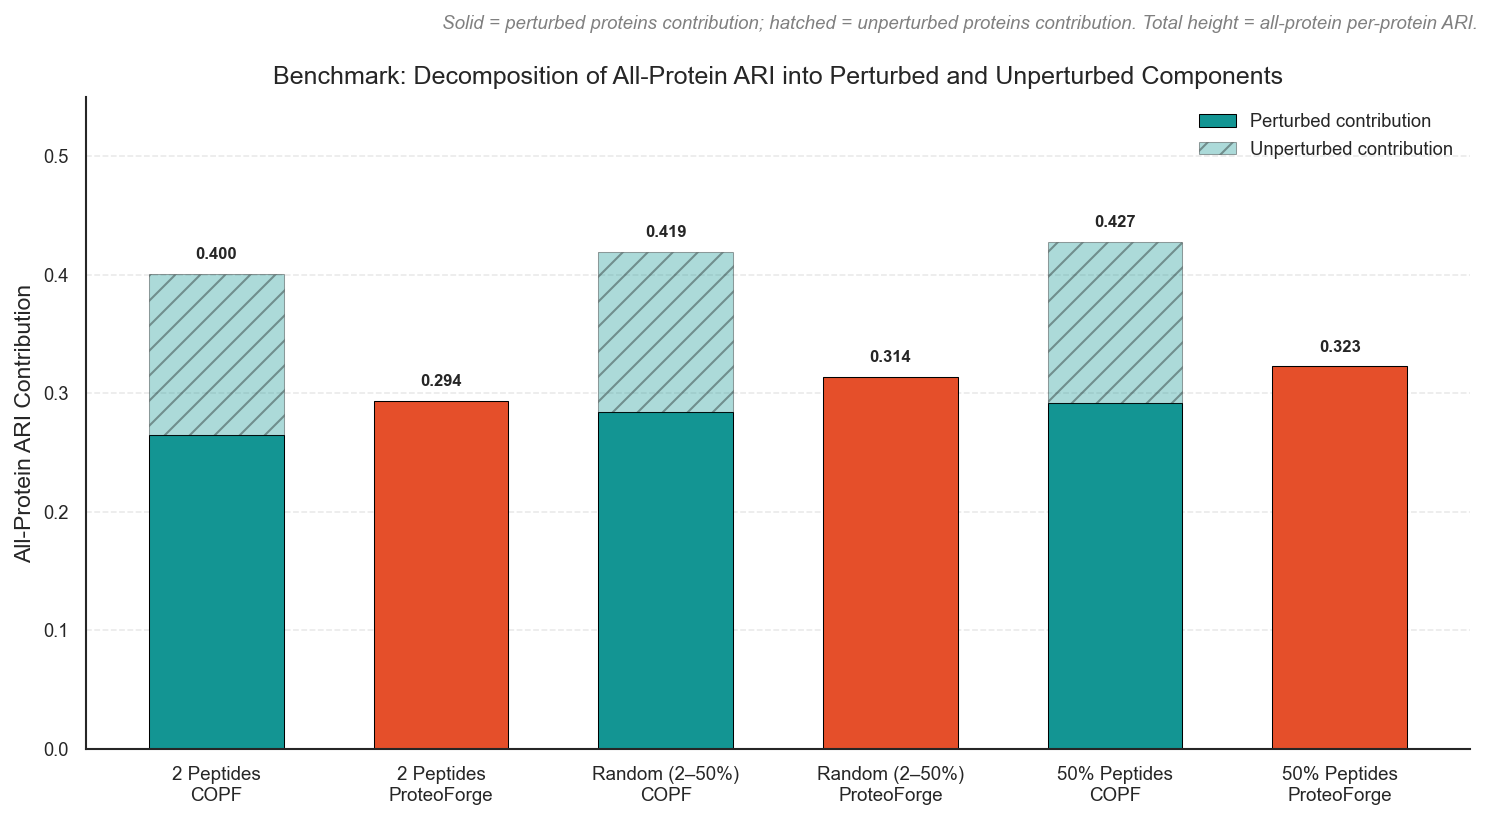

  Saved: ari_decomposition_stacked.png


In [23]:
# ── Stacked bar: visualise perturbed vs unperturbed ARI contributions ─────────
fig, ax = plt.subplots(figsize=(10, 5.5))

group_labels = []
for scenario in BENCH_SCENARIO_ORDER:
    for method in METHOD_ORDER:
        group_labels.append(f'{BENCH_SCENARIO_LABELS.get(scenario, scenario)}\n{method}')

x = np.arange(len(group_labels))
pert_vals, unpert_vals = [], []

for scenario in BENCH_SCENARIO_ORDER:
    for method in METHOD_ORDER:
        row = decomp_df[(decomp_df['Scenario'] == BENCH_SCENARIO_LABELS.get(scenario, scenario)) &
                        (decomp_df['Method'] == method)]
        if row.empty:
            pert_vals.append(0); unpert_vals.append(0)
            continue
        n_p = row['n_pert'].iloc[0]
        n_u = row['n_unpert'].iloc[0]
        n_a = n_p + n_u
        pert_vals.append(row['ARI_pert'].iloc[0] * n_p / n_a)
        unpert_vals.append(row['ARI_unpert'].iloc[0] * n_u / n_a)

colors = [METHOD_COLORS.get(m, '#999') for s in BENCH_SCENARIO_ORDER for m in METHOD_ORDER]

bars1 = ax.bar(x, pert_vals, 0.6, label='Perturbed contribution',
               color=colors, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, unpert_vals, 0.6, bottom=pert_vals,
               label='Unperturbed contribution',
               color=colors, edgecolor='black', linewidth=0.5, alpha=0.35, hatch='//')

# Add total ARI labels
for i, (pv, uv) in enumerate(zip(pert_vals, unpert_vals)):
    total = pv + uv
    ax.text(i, total + 0.01, f'{total:.3f}', ha='center', va='bottom',
            fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(group_labels, fontsize=9, rotation=0)
ax.set_ylabel('All-Protein ARI Contribution')
ax.set_title('Benchmark: Decomposition of All-Protein ARI into Perturbed and Unperturbed Components')
ax.legend(frameon=False, loc='upper right')
ax.set_ylim(0, 0.55)
style_axis(ax)
add_note(fig, 'Solid = perturbed proteins contribution; hatched = unperturbed proteins contribution. '
         'Total height = all-protein per-protein ARI.')
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, 'ari_decomposition_stacked.png', path=bench_figure_path)
plt.show()
print('  Saved: ari_decomposition_stacked.png')

In [24]:
# ── Same pattern in simulation: confirm this is not benchmark-specific ─────────
sim_decomp_rows = []
representative_sims = [
    ('Sim1', '2_twoPep_complete'),
    ('Sim1', '2_randomPep_complete'),
]

for sim_id, scenario in representative_sims:
    for method in METHOD_ORDER:
        pert_row = sim_df[(sim_df['sim_id'] == sim_id) &
                          (sim_df['scenario'] == scenario) &
                          (sim_df['method'] == method) &
                          (sim_df['mode'] == 'perturbed_per_protein')]
        all_row  = sim_df[(sim_df['sim_id'] == sim_id) &
                          (sim_df['scenario'] == scenario) &
                          (sim_df['method'] == method) &
                          (sim_df['mode'] == 'all_per_protein')]
        if pert_row.empty or all_row.empty:
            continue
        n_pert  = int(pert_row['n_proteins'].iloc[0])
        n_all   = int(all_row['n_proteins'].iloc[0])
        n_unpert = n_all - n_pert
        ari_pert = pert_row['ARI'].iloc[0]
        ari_all  = all_row['ARI'].iloc[0]
        ari_unpert = (ari_all * n_all - ari_pert * n_pert) / n_unpert if n_unpert > 0 else np.nan

        sim_decomp_rows.append({
            'Dataset': f'{sim_id}: {scenario}',
            'Method': method,
            'n_pert': n_pert,
            'n_unpert': n_unpert,
            '% Unperturbed': f'{n_unpert/(n_pert+n_unpert):.0%}',
            'ARI_pert': round(ari_pert, 3),
            'ARI_unpert': round(ari_unpert, 3),
            'ARI_all': round(ari_all, 3),
        })

# Add benchmark rows for direct comparison
for scenario in ['2pep']:
    for method in METHOD_ORDER:
        row = decomp_df[(decomp_df['Scenario'] == BENCH_SCENARIO_LABELS.get(scenario, scenario)) &
                        (decomp_df['Method'] == method)]
        if row.empty:
            continue
        sim_decomp_rows.append({
            'Dataset': f'Benchmark: {scenario}',
            'Method': method,
            'n_pert': int(row['n_pert'].iloc[0]),
            'n_unpert': int(row['n_unpert'].iloc[0]),
            '% Unperturbed': row['Unpert Weight'].iloc[0],
            'ARI_pert': row['ARI_pert'].iloc[0],
            'ARI_unpert': row['ARI_unpert'].iloc[0],
            'ARI_all': row['ARI_all'].iloc[0],
        })

sim_decomp_df = pd.DataFrame(sim_decomp_rows)
display(
    sim_decomp_df.style
    .set_caption('Cross-Dataset Comparison: ARI Decomposition Shows Same Pattern in Simulation and Benchmark')
    .hide(axis='index')
    .format({'ARI_pert': '{:.3f}', 'ARI_unpert': '{:.3f}', 'ARI_all': '{:.3f}'})
)

Dataset,Method,n_pert,n_unpert,% Unperturbed,ARI_pert,ARI_unpert,ARI_all
Sim1: 2_twoPep_complete,COPF,250,250,50%,0.363,0.116,0.239
Sim1: 2_twoPep_complete,ProteoForge,250,250,50%,0.841,0.000,0.421
Sim1: 2_randomPep_complete,COPF,250,250,50%,0.338,0.116,0.227
Sim1: 2_randomPep_complete,ProteoForge,250,250,50%,0.882,-0.000,0.441
Benchmark: 2pep,COPF,1000,1217,54.9%,0.587,0.247,0.400
Benchmark: 2pep,ProteoForge,1000,1217,54.9%,0.651,0.000,0.294


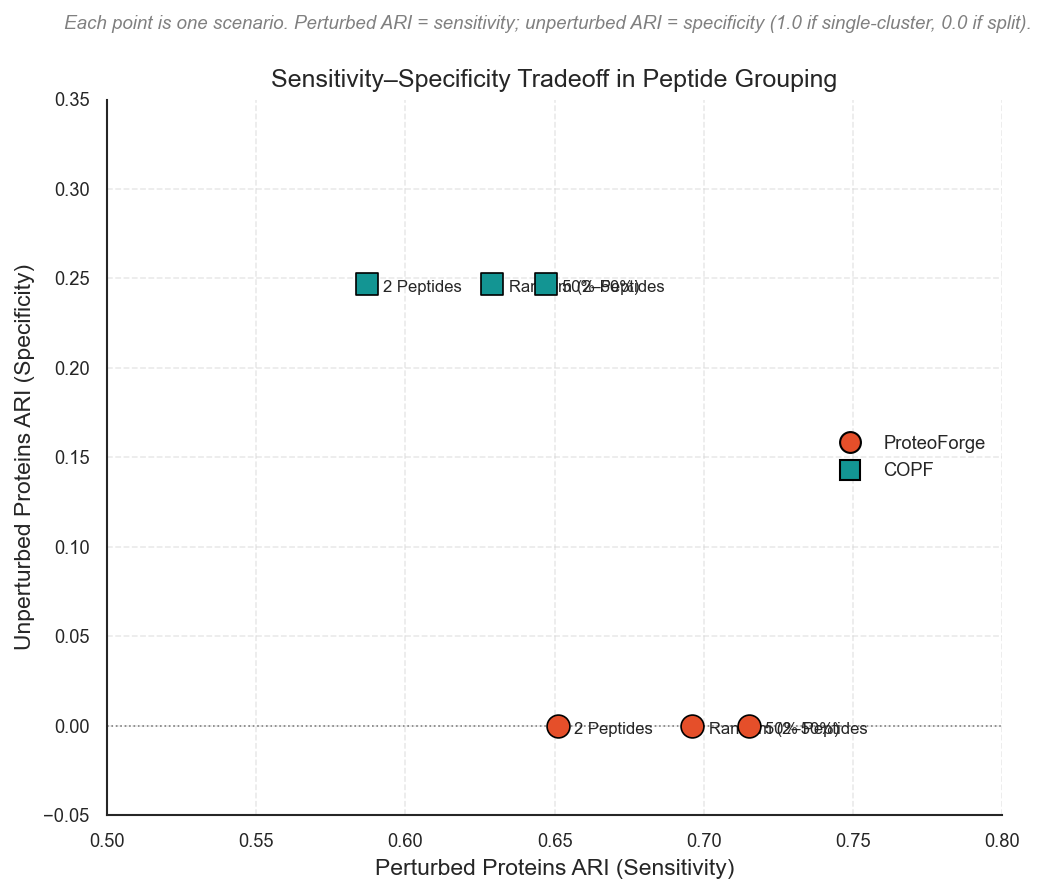

  Saved: sensitivity_specificity_scatter.png


In [25]:
# ── Sensitivity vs Specificity scatter: perturbed ARI vs unperturbed ARI ───────
fig, ax = plt.subplots(figsize=(7, 6))

for scenario in BENCH_SCENARIO_ORDER:
    for method in METHOD_ORDER:
        row = decomp_df[(decomp_df['Scenario'] == BENCH_SCENARIO_LABELS.get(scenario, scenario)) &
                        (decomp_df['Method'] == method)]
        if row.empty:
            continue
        color = METHOD_COLORS.get(method, '#999')
        marker = 'o' if method == 'ProteoForge' else 's'
        ax.scatter(row['ARI_pert'], row['ARI_unpert'], s=120,
                   color=color, marker=marker, edgecolors='black', linewidth=0.8,
                   zorder=5)
        ax.annotate(BENCH_SCENARIO_LABELS.get(scenario, scenario),
                    (row['ARI_pert'].iloc[0], row['ARI_unpert'].iloc[0]),
                    textcoords='offset points', xytext=(8, -4), fontsize=8)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=METHOD_COLORS['ProteoForge'],
           markeredgecolor='black', markersize=10, label='ProteoForge'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=METHOD_COLORS['COPF'],
           markeredgecolor='black', markersize=10, label='COPF'),
]
ax.legend(handles=legend_elements, frameon=False, loc='center right')

ax.set_xlabel('Perturbed Proteins ARI (Sensitivity)')
ax.set_ylabel('Unperturbed Proteins ARI (Specificity)')
ax.set_title('Sensitivity–Specificity Tradeoff in Peptide Grouping')
ax.set_xlim(0.5, 0.8)
ax.set_ylim(-0.05, 0.35)
ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
style_axis(ax, grid_axis='both')
add_note(fig, 'Each point is one scenario. Perturbed ARI = sensitivity; '
         'unperturbed ARI = specificity (1.0 if single-cluster, 0.0 if split).')
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, 'sensitivity_specificity_scatter.png', path=bench_figure_path)
plt.show()
print('  Saved: sensitivity_specificity_scatter.png')

### Interpretation — Method Architecture and the ARI Reversal

The analyses above reveal that the apparent COPF advantage in the all-protein and concatenated ARI modes is driven entirely by **how each method handles unperturbed proteins at the clustering stage**, not by any superiority in detecting true proteoform groups.

**ProteoForge** achieves higher ARI on the perturbed proteins where grouping actually matters (+0.06 to +0.07 across benchmark scenarios). Its dendrogram-based cluster selection always produces $k \geq 2$ clusters when a protein has 4+ peptides, leading to a 100% split rate on unperturbed proteins. Under the ARI scoring rule, every unperturbed protein scores 0.0. However, in ProteoForge's full pipeline, this splitting does not equate to false proteoform calls. Clustering is an intermediate step: each cluster is subsequently evaluated by a per-peptide statistical model, and only clusters containing significantly discordant peptides are classified as differential proteoforms ($\text{dPF} > 0$). Clusters that lack significant peptides — as expected for truly unperturbed proteins — are labeled non-differential ($\text{dPF} = 0$). The ARI metric evaluates the clustering output before this classification step occurs, so it penalizes the exploratory splitting without reflecting the downstream filtering.

**COPF** is more conservative at the clustering stage: it keeps ~25% of unperturbed proteins as a single cluster (ARI = 1.0), giving it a built-in advantage in any evaluation mode that includes unperturbed proteins. This conservatism is functionally important for COPF because its clustering output directly defines proteoform grouping — peptides in different clusters are treated as belonging to different proteoforms. COPF's lower sensitivity on perturbed proteins (-0.06 to -0.07) is masked by this clustering-level specificity advantage when all proteins are pooled.

In the benchmark, 55% of proteins are unperturbed (1,217 / 2,217), and ProteoForge's perturbed-protein advantage cannot overcome the accumulated penalty of 1,217 zero-scoring unperturbed proteins. In simulation (50% unperturbed with a larger perturbed advantage of +0.48), ProteoForge still wins in the all-protein per-protein mode — but even there, COPF edges ahead in the concatenated mode.

**Bottom line:** The perturbed-only per-protein ARI is the only mode free from this architectural confound. The all-protein and concatenated modes should be interpreted with the understanding that they evaluate each method's clustering-stage output, which has different downstream consequences: for COPF, cluster assignments are the proteoform grouping; for ProteoForge, they are candidate groupings that must pass significance testing before becoming proteoform calls.

---

# Part 6: Summary Tables

The tables below consolidate the headline ARI values across all simulations and the benchmark, giving a single reference for the manuscript supplementary note.

In [11]:
# ── Simulation summary (perturbed-only, per-Sim) ─────────────────────────────
sim_perturbed = sim_df[sim_df['mode'] == 'perturbed_per_protein'].copy()

sim_summary = (
    sim_perturbed
    .groupby(['sim_id', 'method'])
    .agg(
        n_scenarios=('scenario', 'nunique'),
        ARI_mean=('ARI', 'mean'),
        ARI_median=('ARI', 'median'),
        ARI_min=('ARI', 'min'),
        ARI_max=('ARI', 'max'),
        mean_CI_width=('CI_width', 'mean'),
    )
    .reset_index()
    .sort_values(['sim_id', 'method'])
)

display(
    sim_summary.style
    .set_caption('Simulation ARI Summary — Perturbed Proteins Only (per-protein mean ARI)')
    .format({
        'ARI_mean': '{:.3f}', 'ARI_median': '{:.3f}',
        'ARI_min': '{:.3f}', 'ARI_max': '{:.3f}',
        'mean_CI_width': '{:.3f}',
    })
)

sim_summary_path = os.path.join(output_path, 'ari_simulation_summary.csv')
sim_summary.to_csv(sim_summary_path, index=False)
print(f'Saved: {project_relative_label(sim_summary_path)}')

,sim_id,method,n_scenarios,ARI_mean,ARI_median,ARI_min,ARI_max,mean_CI_width
0,Sim1,COPF,8,0.230,0.202,0.114,0.363,0.081
1,Sim1,ProteoForge,8,0.681,0.662,0.401,0.882,0.070
2,Sim2,COPF,25,0.199,0.185,0.061,0.374,0.072
3,Sim2,ProteoForge,25,0.589,0.621,0.227,0.847,0.064
4,Sim3,COPF,8,0.236,0.264,0.005,0.404,0.079
5,Sim3,ProteoForge,8,0.571,0.683,0.195,0.716,0.074
6,Sim4,COPF,20,0.272,0.264,0.220,0.347,0.087
7,Sim4,ProteoForge,20,0.635,0.607,0.486,0.785,0.068


Saved: Analysis_with_ProteoForge/Revisions/outputs/simulation/ari_benchmark/ari_simulation_summary.csv


In [12]:
# ── Benchmark summary (all modes) ────────────────────────────────────────────
bench_display = bench_df.copy()
bench_display['CI'] = bench_display.apply(
    lambda r: f"[{r['CI_lower']:.3f}, {r['CI_upper']:.3f}]", axis=1
)

bench_pivot = bench_display.pivot_table(
    index=['scenario', 'method'],
    columns='mode',
    values='ARI',
    aggfunc='first',
).rename_axis(None, axis=1).reset_index()

# Reorder columns
bench_pivot = bench_pivot[[
    'scenario', 'method',
    'perturbed_per_protein', 'all_per_protein', 'concatenated_all'
]]

display(
    bench_pivot.style
    .set_caption('Benchmark ARI — All Reporting Modes')
    .format({
        'perturbed_per_protein': '{:.3f}',
        'all_per_protein': '{:.3f}',
        'concatenated_all': '{:.3f}',
    })
)

,scenario,method,perturbed_per_protein,all_per_protein,concatenated_all
0,050pep,COPF,0.647,0.427,0.745
1,050pep,ProteoForge,0.715,0.322,0.707
2,2pep,COPF,0.587,0.400,0.804
3,2pep,ProteoForge,0.651,0.294,0.687
4,random,COPF,0.629,0.419,0.771
5,random,ProteoForge,0.696,0.314,0.712


In [13]:
# ── Benchmark summary with CIs (for the supplementary) ────────────────────────
bench_ci = bench_df.copy()
bench_ci['ARI_CI'] = bench_ci.apply(
    lambda r: f"{r['ARI']:.3f} [{r['CI_lower']:.3f}, {r['CI_upper']:.3f}]", axis=1
)

bench_ci_pivot = bench_ci.pivot_table(
    index=['scenario', 'method'],
    columns='mode',
    values='ARI_CI',
    aggfunc='first',
).rename_axis(None, axis=1).reset_index()

bench_ci_pivot = bench_ci_pivot[[
    'scenario', 'method',
    'perturbed_per_protein', 'all_per_protein', 'concatenated_all'
]]

display(
    bench_ci_pivot.style
    .set_caption('Benchmark ARI with 95% Bootstrap CIs')
)

bench_ci_path = os.path.join(
    PROJECT_ROOT, 'Revisions', 'outputs', 'benchmark',
    'ari_benchmark', 'ari_benchmark_summary_with_ci.csv'
)
bench_ci_pivot.to_csv(bench_ci_path, index=False)
print(f'Saved: {project_relative_label(bench_ci_path)}')

,scenario,method,perturbed_per_protein,all_per_protein,concatenated_all
0,050pep,COPF,"0.647 [0.621, 0.674]","0.427 [0.407, 0.446]","0.745 [0.721, 0.793]"
1,050pep,ProteoForge,"0.715 [0.691, 0.738]","0.322 [0.303, 0.341]","0.707 [0.689, 0.754]"
2,2pep,COPF,"0.587 [0.559, 0.615]","0.400 [0.380, 0.420]","0.804 [0.774, 0.849]"
3,2pep,ProteoForge,"0.651 [0.625, 0.676]","0.294 [0.275, 0.312]","0.687 [0.661, 0.740]"
4,random,COPF,"0.629 [0.602, 0.657]","0.419 [0.399, 0.438]","0.771 [0.751, 0.811]"
5,random,ProteoForge,"0.696 [0.670, 0.721]","0.314 [0.295, 0.332]","0.712 [0.686, 0.768]"


Saved: Analysis_with_ProteoForge/Revisions/outputs/benchmark/ari_benchmark/ari_benchmark_summary_with_ci.csv


---

## Summary of Findings

The ARI analysis provides a complementary view of peptide grouping quality that goes beyond the binary MCC metric used in the main manuscript.

**Simulation.** ProteoForge consistently achieves higher per-protein ARI than COPF across all four simulation axes. The advantage is most pronounced in challenging scenarios: high missingness (Sim2), low perturbation magnitude (Sim3), and multi-condition designs with non-overlapping effects (Sim4). In Sim1, ProteoForge's ARI remains above 0.80 for the `twoPep` and `randomPep` scenarios (complete data), while COPF peaks around 0.30–0.40 in the same settings. When more than half the peptides are perturbed (`halfPlusPep`), both methods are closer, consistent with the known structural limitation at high perturbation fractions discussed in the main text.

**Missingness impact.** The Sim2 heatmaps show a clear gradient: ARI degrades with increasing missingness for both methods, but ProteoForge retains higher accuracy at moderate missingness levels (20% protein, 20% peptide) where real-world datasets typically operate.

**Magnitude sensitivity.** Both methods struggle at very low perturbation magnitudes (<0.5 log₂FC), but ProteoForge shows a steeper recovery curve, reaching reliable grouping (ARI > 0.5) at lower magnitudes than COPF.

**Benchmark replication.** The SWATH-MS benchmark results confirm the simulation findings in the perturbed-only mode: ProteoForge outperforms COPF across all three benchmark scenarios, with the largest margin in the `050pep` (50% peptides) condition.

**Mode sensitivity and the all-protein reversal.** In the all-protein per-protein and concatenated evaluation modes, COPF appears to outperform ProteoForge — a reversal of the perturbed-only ranking. Part 5b traced this reversal to a fundamental difference in how each method uses clustering.

ProteoForge's dendrogram-based algorithm produces $\geq 2$ clusters for every protein with 4+ peptides, yielding ARI = 0.0 for all 1,217 unperturbed benchmark proteins. However, in ProteoForge's pipeline, clustering is an **intermediate organizational step** — not the proteoform determination itself. After clustering, each cluster undergoes per-peptide significance testing: only clusters with significantly discordant peptides are classified as differential proteoforms ($\text{dPF} > 0$), while clusters lacking significance are labeled non-differential ($\text{dPF} = 0$). This means the cluster-level splitting penalized by ARI does not directly translate to false proteoform calls in ProteoForge's full workflow.

COPF's more conservative clustering keeps ~25% of unperturbed proteins in a single cluster (ARI = 1.0). This conservatism matters more for COPF because its clustering output directly determines proteoform grouping — peptides assigned to different clusters are treated as different proteoforms. The resulting specificity advantage dominates the all-protein and concatenated scores when unperturbed proteins comprise 55% of the benchmark. The same pattern is present in the simulation data, confirming it is algorithmic.

**Recommendation.** The perturbed-only per-protein ARI is the primary metric and the only mode free from the architectural confound. The all-protein and concatenated modes evaluate raw cluster assignments, which serve different purposes in each method: a final grouping product for COPF versus an intermediate input to significance testing for ProteoForge. These modes should be interpreted with that distinction in mind.

---
## Notebook Complete